In [2]:
import xarray as xr
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_5_onestep_l1_nofc_aheadtop_05_addprecipnorm/prcp_downs_unet_year_2020.nc")
ds

<xarray.Dataset>
Dimensions:    (time: 6912, lat_in: 16, lon_in: 16, lat: 160, lon: 160,
                pitch_idx: 6912)
Coordinates:
  * time       (time) datetime64[ns] 2020-02-01T06:00:00 ... 2020-12-01T02:00:00
  * pitch_idx  (pitch_idx) int32 1 2 3 4 5 6 7 ... 6907 6908 6909 6910 6911 6912
Dimensions without coordinates: lat_in, lon_in, lat, lon
Data variables:
    inputs     (time, lat_in, lon_in) float32 ...
    inter      (time, lat, lon) float32 ...
    fcst       (time, lat, lon) float32 ...
    hr         (time, lat, lon) float32 ...
    lats       (time, lat) float32 ...
    lons       (time, lon) float32 ...
    tops       (time, lat, lon) float32 ...
Attributes:
    description:  Precipitation downscaling data.

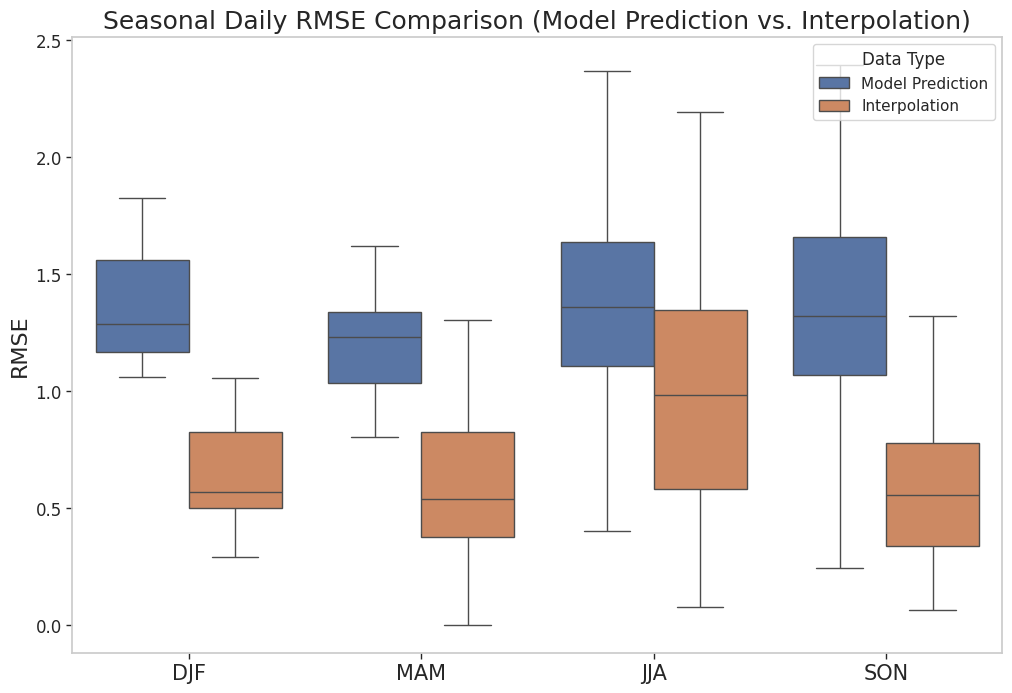

In [11]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")

# 提取变量
fcst = ds['fcst']  # 模型预测结果
hr = ds['hr']      # 高分辨率雷达观测
inter = ds['inter']  # 双三线插值结果
time = pd.to_datetime(ds['time'].values)  # 时间坐标

# 计算按天 RMSE 函数
def calculate_daily_rmse(pred, obs):
    daily_rmse = []
    pred_grouped = pred.groupby('time.date')
    obs_grouped = obs.groupby('time.date')

    for day in pred_grouped.groups:
        pred_data = pred_grouped[day].values.reshape(-1)
        obs_data = obs_grouped[day].values.reshape(-1)
        
        # 计算 RMSE，避免无效数据
        if np.all(np.isnan(pred_data)) or np.all(np.isnan(obs_data)):
            continue
        
        rmse = np.sqrt(np.mean((pred_data - obs_data) ** 2))
        daily_rmse.append({'date': day, 'rmse': rmse})
    
    return pd.DataFrame(daily_rmse)

# 计算 fcst 和 inter 相对于 hr 的 RMSE
df_fcst = calculate_daily_rmse(fcst, hr)
df_inter = calculate_daily_rmse(inter, hr)

# 添加模型类型
df_fcst['Type'] = 'Model Prediction'
df_inter['Type'] = 'Interpolation'
df = pd.concat([df_fcst, df_inter])

# 将日期转换为 datetime 格式
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# 季节映射
def get_season(month):
    if month in [12, 1, 2]:
        return 'DJF'  # 冬季：December, January, February
    elif month in [3, 4, 5]:
        return 'MAM'  # 春季：March, April, May
    elif month in [6, 7, 8]:
        return 'JJA'  # 夏季：June, July, August
    else:
        return 'SON'  # 秋季：September, October, November

df['season'] = df['month'].map(get_season)

# 设置绘图风格
sns.set(style="whitegrid")

# 绘制箱线图，禁用离群点
plt.figure(figsize=(12, 8))
sns.boxplot(x='season', y='rmse', hue='Type', data=df,
            order=['DJF', 'MAM', 'JJA', 'SON'],
            showfliers=False)  # 不显示离群点

# 美化图表
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.title('Seasonal Daily RMSE Comparison (Model Prediction vs. Interpolation)', fontsize=18)
plt.xlabel('')  
plt.ylabel('RMSE', fontsize=16)

plt.xticks(fontsize=15)
plt.yticks(fontsize=12)

# 关闭网格线但保留刻度线
plt.grid(False)  
plt.tick_params(axis='x', which='both', bottom=True, top=False)  # 保留X轴刻度
plt.tick_params(axis='y', which='both', left=True, right=False)  # 保留Y轴刻度

# 设置小刻度
plt.gca().tick_params(axis='both', which='major', length=4, width=1)  # 主刻度加长加粗
plt.gca().tick_params(axis='both', which='minor', length=2, width=0.7)  # 小刻度稍短稍细

plt.legend(title='Data Type', loc='upper right')
plt.show()


## 需要老师的check

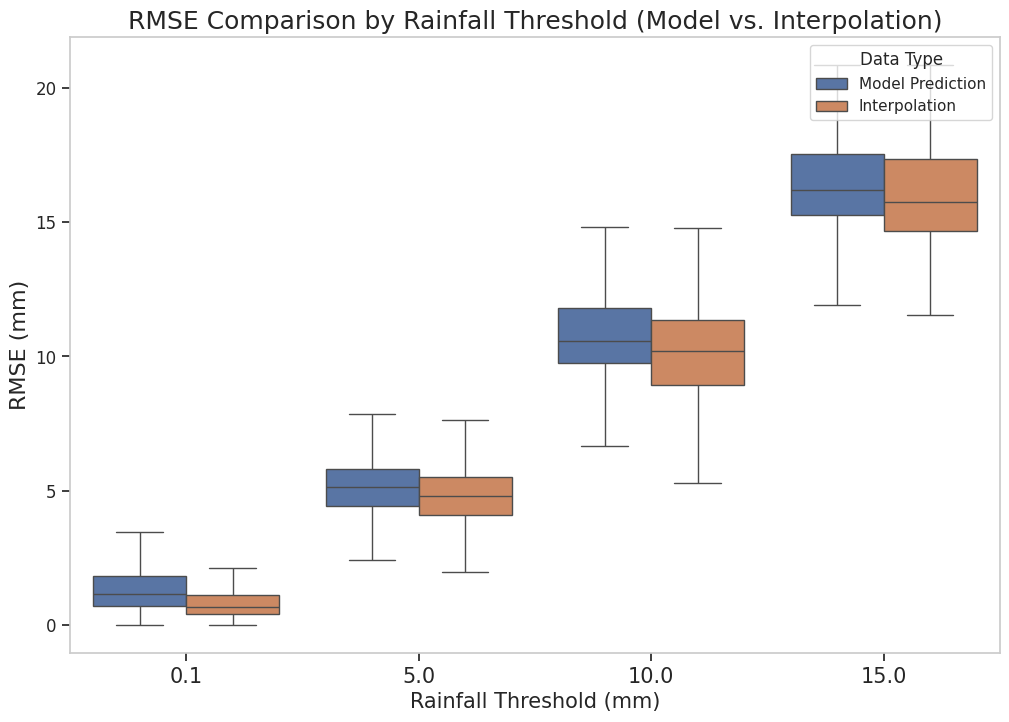

In [9]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")

# 提取变量
fcst = ds['fcst'].values  # 模型预测结果
hr = ds['hr'].values      # 高分辨率雷达观测
inter = ds['inter'].values  # 双三线插值结果
time = pd.to_datetime(ds['time'].values)  # 时间坐标

# 降水强度阈值列表
grade_list = [0.1, 5, 10, 15]

# 计算逐时间片的 RMSE
def calculate_rmse_by_threshold(fcst, hr, grade_list):
    rmse_dict = {grade: [] for grade in grade_list}  # 按阈值存储 RMSE 结果
    
    # 遍历每个时间片，计算不同降水强度下的 RMSE
    for i in range(hr.shape[0]):
        hr_data = hr[i].flatten()
        fcst_data = fcst[i].flatten()
        
        for grade in grade_list:
            # 只计算超过阈值的降水点的 RMSE
            mask = hr_data >= grade
            if np.any(mask):
                rmse = np.sqrt(np.mean((fcst_data[mask] - hr_data[mask]) ** 2))
            else:
                rmse = np.nan  # 如果无降水超过阈值，填充 NaN
            rmse_dict[grade].append(rmse)
    
    return rmse_dict

# 计算模型预测和插值的 RMSE
rmse_fcst = calculate_rmse_by_threshold(fcst, hr, grade_list)
rmse_inter = calculate_rmse_by_threshold(inter, hr, grade_list)

# **解决长度不一致问题**
def pad_dict_to_same_length(rmse_dict):
    max_length = max(len(v) for v in rmse_dict.values())  # 找到最大长度
    for k, v in rmse_dict.items():
        if len(v) < max_length:
            v.extend([np.nan] * (max_length - len(v)))  # 填充 NaN
    return rmse_dict

# 对 FCST 和 INTER 的字典进行填充
rmse_fcst = pad_dict_to_same_length(rmse_fcst)
rmse_inter = pad_dict_to_same_length(rmse_inter)

# 将 RMSE 结果转换为 DataFrame
df_fcst = pd.DataFrame(rmse_fcst).melt(var_name='Threshold', value_name='RMSE')
df_fcst['Type'] = 'Model Prediction'

df_inter = pd.DataFrame(rmse_inter).melt(var_name='Threshold', value_name='RMSE')
df_inter['Type'] = 'Interpolation'

df = pd.concat([df_fcst, df_inter])  # 合并两个结果

# **去除 NaN 以避免绘图错误**
df = df.dropna(subset=['RMSE']) 

# 设置绘图风格
sns.set(style="whitegrid")

# 绘制箱线图（不同降水阈值下的 RMSE 比较）
plt.figure(figsize=(12, 8))
sns.boxplot(x='Threshold', y='RMSE', hue='Type', data=df,
            showfliers=False)  # 不显示离群点

# 美化图表
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.title('RMSE Comparison by Rainfall Threshold (Model vs. Interpolation)', fontsize=18)
plt.xlabel('Rainfall Threshold (mm)', fontsize=15)  
plt.ylabel('RMSE (mm)', fontsize=16)

plt.xticks(fontsize=15)
plt.yticks(fontsize=12)

plt.grid(False)  
plt.tick_params(axis='x', which='both', bottom=True, top=False)  # 保留X轴刻度
plt.tick_params(axis='y', which='both', left=True, right=False)  # 保留Y轴刻度

plt.legend(title='Data Type', loc='upper right')
plt.show()


## 需要老师的check

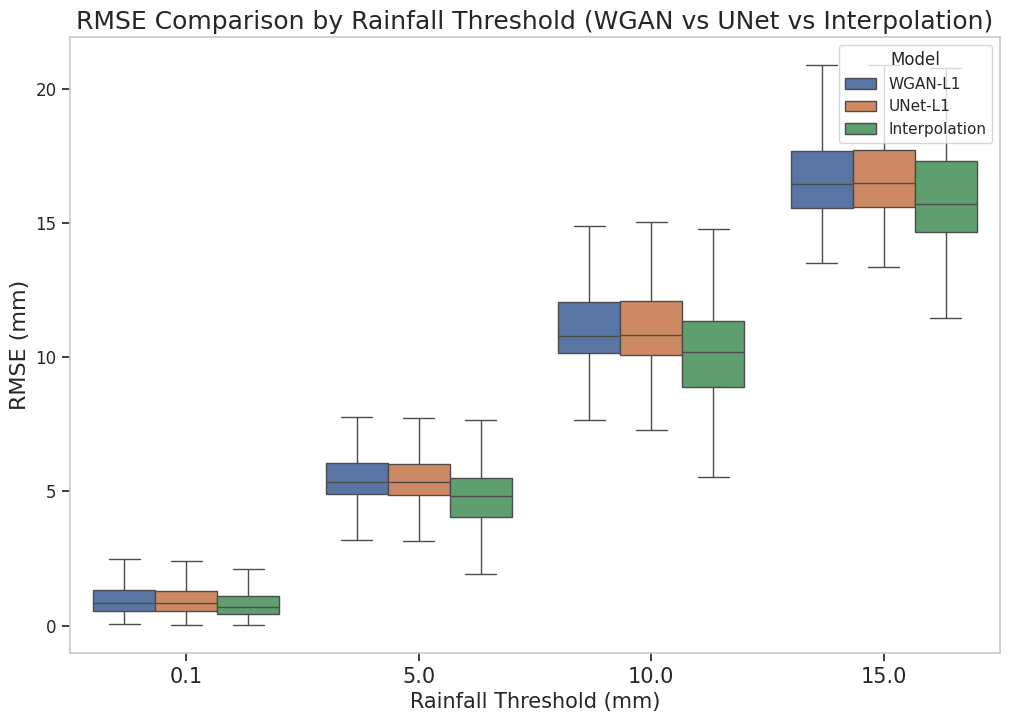

In [26]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 加载 WGAN-L1 数据集
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_11_onestepwgan_cri5_850_l1_aheadtop_10_160epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan = ds_wgan['fcst'].values
hr_wgan = ds_wgan['hr'].values
inter = ds_wgan['inter'].values 

# 加载 UNet-L1 数据集
ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet = ds_unet['fcst'].values
hr_unet = ds_unet['hr'].values

# 降水强度阈值列表
grade_list = [0.1, 5, 10, 15]

# 计算逐时间片的 RMSE
def calculate_rmse_by_threshold(fcst, hr, grade_list):
    rmse_dict = {grade: [] for grade in grade_list}  # 按阈值存储 RMSE 结果
    
    # 遍历每个时间片，计算不同降水强度下的 RMSE
    for i in range(hr.shape[0]):
        hr_data = hr[i].flatten()
        fcst_data = fcst[i].flatten()
        
        for grade in grade_list:
            # 只计算超过阈值的降水点的 RMSE
            mask = hr_data >= grade
            if np.any(mask):
                rmse = np.sqrt(np.mean((fcst_data[mask] - hr_data[mask]) ** 2))
            else:
                rmse = np.nan  # 如果无降水超过阈值，填充 NaN
            rmse_dict[grade].append(rmse)
    
    return rmse_dict

# 计算 WGAN 和 UNet 的 RMSE
rmse_fcst_wgan = calculate_rmse_by_threshold(fcst_wgan, hr_wgan, grade_list)
rmse_fcst_unet = calculate_rmse_by_threshold(fcst_unet, hr_unet, grade_list)
rmse_inter = calculate_rmse_by_threshold(inter, hr_wgan, grade_list) 

# 解决长度不一致问题
def pad_dict_to_same_length(rmse_dict):
    max_length = max(len(v) for v in rmse_dict.values())
    for k, v in rmse_dict.items():
        if len(v) < max_length:
            v.extend([np.nan] * (max_length - len(v)))
    return rmse_dict

rmse_fcst_wgan = pad_dict_to_same_length(rmse_fcst_wgan)
rmse_fcst_unet = pad_dict_to_same_length(rmse_fcst_unet)
rmse_inter = pad_dict_to_same_length(rmse_inter)

# 转换为 DataFrame
df_wgan = pd.DataFrame(rmse_fcst_wgan).melt(var_name='Threshold', value_name='RMSE')
df_wgan['Type'] = 'WGAN-L1'

df_unet = pd.DataFrame(rmse_fcst_unet).melt(var_name='Threshold', value_name='RMSE')
df_unet['Type'] = 'UNet-L1'

df_inter = pd.DataFrame(rmse_inter).melt(var_name='Threshold', value_name='RMSE')
df_inter['Type'] = 'Interpolation'

df = pd.concat([df_wgan, df_unet, df_inter])  # 合并三个结果

# 去除 NaN
df = df.dropna(subset=['RMSE'])

sns.set(style="whitegrid")

# 绘制箱线图
plt.figure(figsize=(12, 8))
sns.boxplot(x='Threshold', y='RMSE', hue='Type', data=df, showfliers=False)  # 不显示离群点

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.title('RMSE Comparison by Rainfall Threshold (WGAN vs UNet vs Interpolation)', fontsize=18)
plt.xlabel('Rainfall Threshold (mm)', fontsize=15)
plt.ylabel('RMSE (mm)', fontsize=16)

plt.xticks(fontsize=15)
plt.yticks(fontsize=12)

plt.grid(False)
plt.tick_params(axis='x', which='both', bottom=True, top=False)
plt.tick_params(axis='y', which='both', left=True, right=False)

plt.legend(title='Model', loc='upper right')
plt.show()


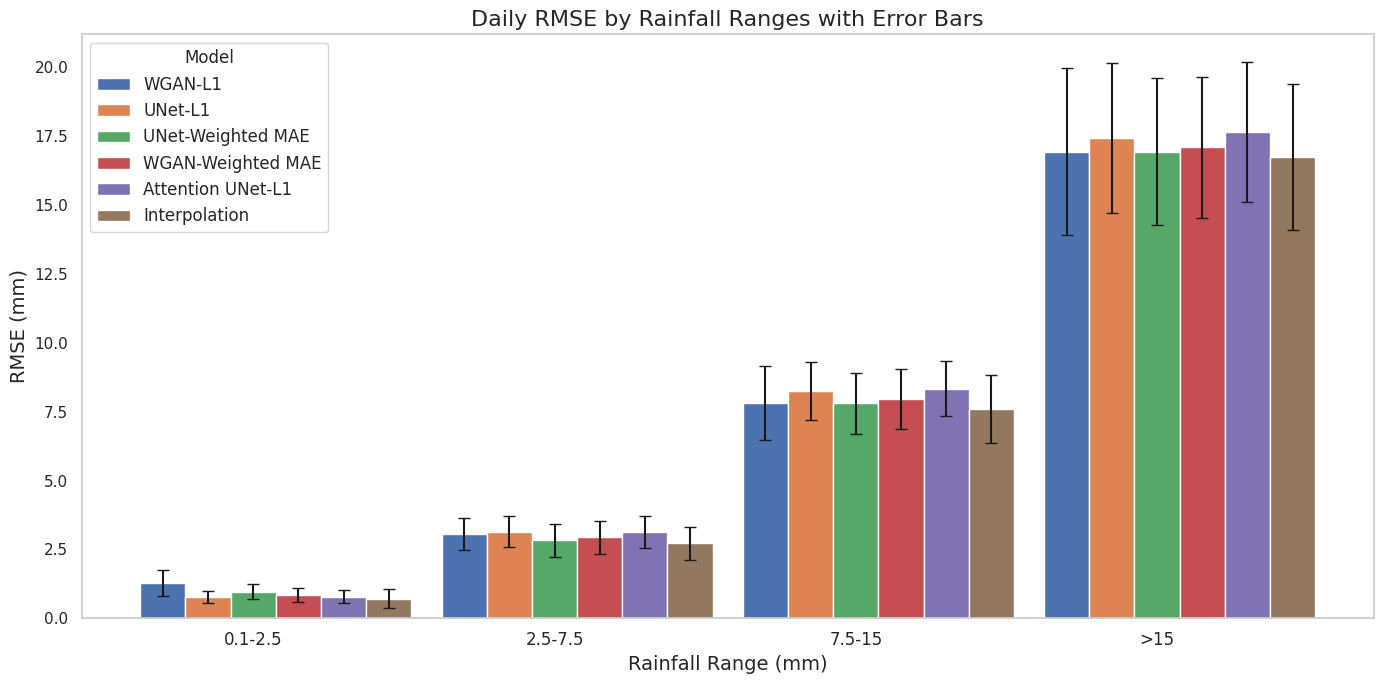

In [20]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan = ds_wgan['fcst']
hr_wgan = ds_wgan['hr']
inter = ds_wgan['inter']

ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet = ds_unet['fcst']
hr_unet = ds_unet['hr']

ds_unet_wmae = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_6_onestep_weightmae_aheadtop_10_addprecipnorm_08_8_70_145/prcp_downs_unet_year_2020.nc")
fcst_unet_wmae = ds_unet_wmae['fcst']
hr_unet_wmae = ds_unet_wmae['hr']

ds_wgan_wmae = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_0_1_onestepwgan_cri5_1000_weightmae_1.5_6_60_120_aheadtop_10_160epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan_wmae = ds_wgan_wmae['fcst']
hr_wgan_wmae = ds_wgan_wmae['hr']

# 加载 Attention UNet-L1 数据集
ds_attention_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_0_1_onestep_atteintionunet_l1_aheadtop_10_addprecipnorm/prcp_downs_attention_unet_year_2020.nc")
fcst_attention_unet = ds_attention_unet['fcst']
hr_attention_unet = ds_attention_unet['hr']

# 定义降水区间
grade_ranges = [(0.1, 2.5), (2.5, 7.5), (7.5, 15), (15, np.inf)]

# 按降水区间计算每日 RMSE
def calculate_daily_rmse_by_ranges(fcst, hr, grade_ranges):
    rmse_dict = {f"{low}-{high}" if high != np.inf else f">{low}": [] for low, high in grade_ranges}
    fcst_grouped = fcst.groupby('time.date')
    hr_grouped = hr.groupby('time.date')

    for day in fcst_grouped.groups:
        fcst_data = fcst_grouped[day].values.reshape(-1)
        hr_data = hr_grouped[day].values.reshape(-1)
        
        for low, high in grade_ranges:
            mask = (hr_data >= low) & (hr_data < high)
            if np.any(mask):
                rmse = np.sqrt(np.mean((fcst_data[mask] - hr_data[mask]) ** 2))
            else:
                rmse = np.nan
            rmse_dict[f"{low}-{high}" if high != np.inf else f">{low}"].append(rmse)
    
    return rmse_dict

# 计算 RMSE
rmse_fcst_wgan = calculate_daily_rmse_by_ranges(fcst_wgan, hr_wgan, grade_ranges)
rmse_fcst_unet = calculate_daily_rmse_by_ranges(fcst_unet, hr_unet, grade_ranges)
rmse_fcst_unet_wmae = calculate_daily_rmse_by_ranges(fcst_unet_wmae, hr_unet_wmae, grade_ranges)
rmse_fcst_wgan_wmae = calculate_daily_rmse_by_ranges(fcst_wgan_wmae, hr_wgan_wmae, grade_ranges)
rmse_fcst_attention_unet = calculate_daily_rmse_by_ranges(fcst_attention_unet, hr_attention_unet, grade_ranges)
rmse_inter = calculate_daily_rmse_by_ranges(inter, hr_wgan, grade_ranges)

# 转换为均值和标准差
def calculate_mean_std(rmse_dict):
    mean_std_dict = {}
    for key, values in rmse_dict.items():
        mean_std_dict[key] = {
            'mean': np.nanmean(values),
            'std': np.nanstd(values)
        }
    return mean_std_dict

mean_std_wgan = calculate_mean_std(rmse_fcst_wgan)
mean_std_unet = calculate_mean_std(rmse_fcst_unet)
mean_std_unet_wmae = calculate_mean_std(rmse_fcst_unet_wmae)
mean_std_wgan_wmae = calculate_mean_std(rmse_fcst_wgan_wmae)
mean_std_attention_unet = calculate_mean_std(rmse_fcst_attention_unet)
mean_std_inter = calculate_mean_std(rmse_inter)

# 转换为 DataFrame
thresholds = list(mean_std_wgan.keys())
models = ['WGAN-L1', 'UNet-L1', 'UNet-Weighted MAE', 'WGAN-Weighted MAE', 'Attention UNet-L1', 'Interpolation']

mean_df = pd.DataFrame({
    'Threshold': thresholds,
    'WGAN-L1': [mean_std_wgan[t]['mean'] for t in thresholds],
    'UNet-L1': [mean_std_unet[t]['mean'] for t in thresholds],
    'UNet-Weighted MAE': [mean_std_unet_wmae[t]['mean'] for t in thresholds],
    'WGAN-Weighted MAE': [mean_std_wgan_wmae[t]['mean'] for t in thresholds],
    'Attention UNet-L1': [mean_std_attention_unet[t]['mean'] for t in thresholds],
    'Interpolation': [mean_std_inter[t]['mean'] for t in thresholds]
})

std_df = pd.DataFrame({
    'Threshold': thresholds,
    'WGAN-L1': [mean_std_wgan[t]['std'] for t in thresholds],
    'UNet-L1': [mean_std_unet[t]['std'] for t in thresholds],
    'UNet-Weighted MAE': [mean_std_unet_wmae[t]['std'] for t in thresholds],
    'WGAN-Weighted MAE': [mean_std_wgan_wmae[t]['std'] for t in thresholds],
    'Attention UNet-L1': [mean_std_attention_unet[t]['std'] for t in thresholds],
    'Interpolation': [mean_std_inter[t]['std'] for t in thresholds]
})

# 绘制柱状图
bar_width = 0.15
x = np.arange(len(thresholds))  # Threshold位置

plt.figure(figsize=(14, 7))

for i, model in enumerate(models):
    plt.bar(x + i * bar_width, mean_df[model], width=bar_width, yerr=std_df[model], label=model, capsize=4)

plt.xticks(x + bar_width * 2, thresholds, fontsize=12)
plt.xlabel('Rainfall Range (mm)', fontsize=14)
plt.ylabel('RMSE (mm)', fontsize=14)
plt.title('Daily RMSE by Rainfall Ranges with Error Bars', fontsize=16)
plt.legend(title='Model', fontsize=12, loc='upper left')
plt.tight_layout()
plt.grid(False)
plt.show()


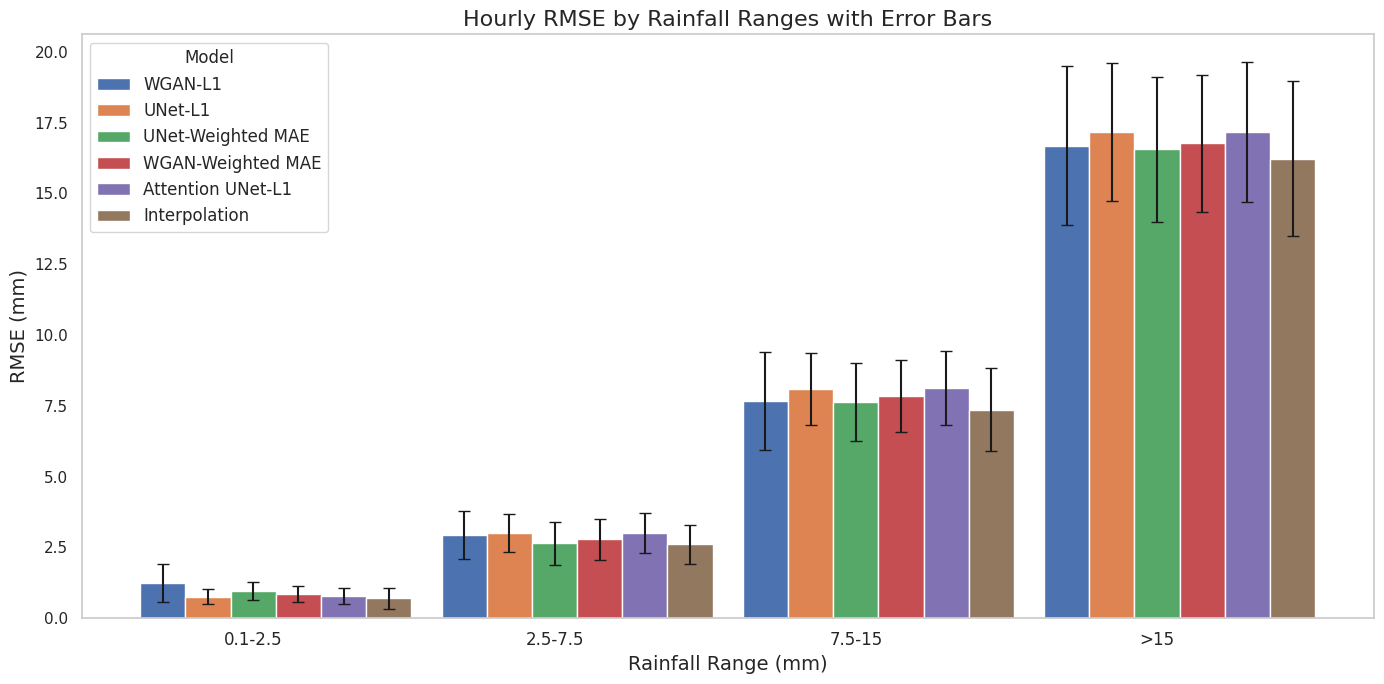

In [21]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 加载 WGAN-L1 数据集
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan = ds_wgan['fcst']
hr_wgan = ds_wgan['hr']
inter = ds_wgan['inter']

# 加载 UNet-L1 数据集
ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet = ds_unet['fcst']
hr_unet = ds_unet['hr']

# 加载 UNet-Weighted MAE 数据集
ds_unet_wmae = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_6_onestep_weightmae_aheadtop_10_addprecipnorm_08_8_70_145/prcp_downs_unet_year_2020.nc")
fcst_unet_wmae = ds_unet_wmae['fcst']
hr_unet_wmae = ds_unet_wmae['hr']

# 加载 wgan-Weighted MAE 数据集
ds_wgan_wmae = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_0_1_onestepwgan_cri5_1000_weightmae_1.5_6_60_120_aheadtop_10_160epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan_wmae = ds_wgan_wmae['fcst']
hr_wgan_wmae = ds_wgan_wmae['hr']

# 加载 Attention UNet-L1 数据集
ds_attention_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_0_1_onestep_atteintionunet_l1_aheadtop_10_addprecipnorm/prcp_downs_attention_unet_year_2020.nc")
fcst_attention_unet = ds_attention_unet['fcst']
hr_attention_unet = ds_attention_unet['hr']

# 定义降水区间（上下限）
grade_ranges = [(0.1, 2.5), (2.5, 7.5), (7.5, 15), (15, np.inf)]

# 计算按降水区间的 RMSE（同一天同时间点的所有降水整合在一起）
def calculate_daily_rmse_by_ranges(fcst, hr, grade_ranges):
    rmse_dict = {f"{low}-{high}" if high != np.inf else f">{low}": [] for low, high in grade_ranges}

    # 创建 DataArray 来提取日期和小时信息
    time_dates = fcst['time'].dt.date
    time_hours = fcst['time'].dt.hour

    # 创建一个新的 DataArray，作为索引将时间与小时合并
    time_combined = xr.DataArray(
        [f"{date}_{hour}" for date, hour in zip(time_dates.values, time_hours.values)],
        coords=[fcst['time']],
        dims=["time"],
        name="time_combined"
    )

    # 按天和时间分组
    fcst_grouped = fcst.groupby(time_combined)
    hr_grouped = hr.groupby(time_combined)

    # 遍历每一天和每个时间点
    for time_idx in fcst_grouped.groups:
        fcst_data = fcst_grouped[time_idx].values.flatten()  # 将该时间点的所有空间降水数据展平
        hr_data = hr_grouped[time_idx].values.flatten()  # 展平目标高分辨率数据
        
        for low, high in grade_ranges:
            mask = (hr_data >= low) & (hr_data < high)
            if np.any(mask):
                rmse = np.sqrt(np.mean((fcst_data[mask] - hr_data[mask]) ** 2))
            else:
                rmse = np.nan
            rmse_dict[f"{low}-{high}" if high != np.inf else f">{low}"].append(rmse)
    
    return rmse_dict


# 计算 RMSE
rmse_fcst_wgan = calculate_daily_rmse_by_ranges(fcst_wgan, hr_wgan, grade_ranges)
rmse_fcst_unet = calculate_daily_rmse_by_ranges(fcst_unet, hr_unet, grade_ranges)
rmse_fcst_unet_wmae = calculate_daily_rmse_by_ranges(fcst_unet_wmae, hr_unet_wmae, grade_ranges)
rmse_fcst_wgan_wmae = calculate_daily_rmse_by_ranges(fcst_wgan_wmae, hr_wgan_wmae, grade_ranges)
rmse_fcst_attention_unet = calculate_daily_rmse_by_ranges(fcst_attention_unet, hr_attention_unet, grade_ranges)
rmse_inter = calculate_daily_rmse_by_ranges(inter, hr_wgan, grade_ranges)

# 转换为均值和标准差
def calculate_mean_std(rmse_dict):
    mean_std_dict = {}
    for key, values in rmse_dict.items():
        mean_std_dict[key] = {
            'mean': np.nanmean(values),
            'std': np.nanstd(values)
        }
    return mean_std_dict

mean_std_wgan = calculate_mean_std(rmse_fcst_wgan)
mean_std_unet = calculate_mean_std(rmse_fcst_unet)
mean_std_unet_wmae = calculate_mean_std(rmse_fcst_unet_wmae)
mean_std_wgan_wmae = calculate_mean_std(rmse_fcst_wgan_wmae)
mean_std_attention_unet = calculate_mean_std(rmse_fcst_attention_unet)
mean_std_inter = calculate_mean_std(rmse_inter)

# 转换为 DataFrame
thresholds = list(mean_std_wgan.keys())
models = ['WGAN-L1', 'UNet-L1', 'UNet-Weighted MAE', 'WGAN-Weighted MAE', 'Attention UNet-L1', 'Interpolation']

mean_df = pd.DataFrame({
    'Threshold': thresholds,
    'WGAN-L1': [mean_std_wgan[t]['mean'] for t in thresholds],
    'UNet-L1': [mean_std_unet[t]['mean'] for t in thresholds],
    'UNet-Weighted MAE': [mean_std_unet_wmae[t]['mean'] for t in thresholds],
    'WGAN-Weighted MAE': [mean_std_wgan_wmae[t]['mean'] for t in thresholds],
    'Attention UNet-L1': [mean_std_attention_unet[t]['mean'] for t in thresholds],
    'Interpolation': [mean_std_inter[t]['mean'] for t in thresholds]
})

std_df = pd.DataFrame({
    'Threshold': thresholds,
    'WGAN-L1': [mean_std_wgan[t]['std'] for t in thresholds],
    'UNet-L1': [mean_std_unet[t]['std'] for t in thresholds],
    'UNet-Weighted MAE': [mean_std_unet_wmae[t]['std'] for t in thresholds],
    'WGAN-Weighted MAE': [mean_std_wgan_wmae[t]['std'] for t in thresholds],
    'Attention UNet-L1': [mean_std_attention_unet[t]['std'] for t in thresholds],
    'Interpolation': [mean_std_inter[t]['std'] for t in thresholds]
})

# 绘制柱状图
bar_width = 0.15
x = np.arange(len(thresholds))  # Threshold位置

plt.figure(figsize=(14, 7))

for i, model in enumerate(models):
    plt.bar(x + i * bar_width, mean_df[model], width=bar_width, yerr=std_df[model], label=model, capsize=4)

plt.xticks(x + bar_width * 2, thresholds, fontsize=12)
plt.xlabel('Rainfall Range (mm)', fontsize=14)
plt.ylabel('RMSE (mm)', fontsize=14)
plt.title('Hourly RMSE by Rainfall Ranges with Error Bars', fontsize=16)
plt.legend(title='Model', fontsize=12, loc='upper left')
plt.tight_layout()
plt.grid(False)
plt.show()


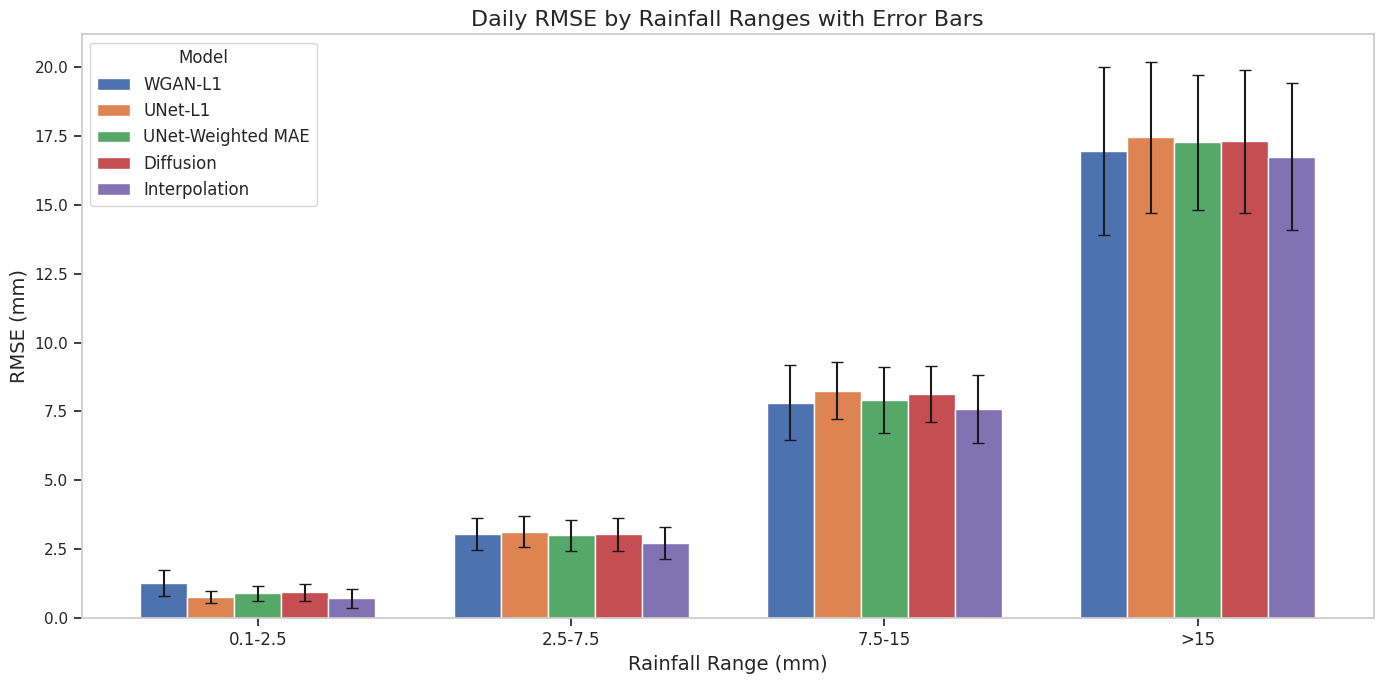

In [4]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan = ds_wgan['fcst']
hr_wgan = ds_wgan['hr']
inter = ds_wgan['inter']

ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet = ds_unet['fcst']
hr_unet = ds_unet['hr']

ds_unet_wmae = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_3_onestep_weightmae_aheadtop_10_addprecipnorm_15_6_60_120/prcp_downs_unet_year_2020.nc")
fcst_unet_wmae = ds_unet_wmae['fcst']
hr_unet_wmae = ds_unet_wmae['hr']

# 加载 Diffusion 模型数据
ds_diffusion = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex61_onestepdiffusion_dividemax_minmaxnormlazie_timesteps250_l2_droptop_0.5_150epoch/corrected_prcp_downs_global.nc")
fcst_diffusion = ds_diffusion['fcst_corrected']
hr_diffusion = ds_diffusion['hr']

# 定义降水区间
grade_ranges = [(0.1, 2.5), (2.5, 7.5), (7.5, 15), (15, np.inf)]

# 按降水区间计算每日 RMSE
def calculate_daily_rmse_by_ranges(fcst, hr, grade_ranges):
    rmse_dict = {f"{low}-{high}" if high != np.inf else f">{low}": [] for low, high in grade_ranges}
    fcst_grouped = fcst.groupby('time.date')
    hr_grouped = hr.groupby('time.date')

    for day in fcst_grouped.groups:
        fcst_data = fcst_grouped[day].values.reshape(-1)
        hr_data = hr_grouped[day].values.reshape(-1)
        
        for low, high in grade_ranges:
            mask = (hr_data >= low) & (hr_data < high)
            if np.any(mask):
                rmse = np.sqrt(np.mean((fcst_data[mask] - hr_data[mask]) ** 2))
            else:
                rmse = np.nan
            rmse_dict[f"{low}-{high}" if high != np.inf else f">{low}"].append(rmse)
    
    return rmse_dict

# 计算 RMSE
rmse_fcst_wgan = calculate_daily_rmse_by_ranges(fcst_wgan, hr_wgan, grade_ranges)
rmse_fcst_unet = calculate_daily_rmse_by_ranges(fcst_unet, hr_unet, grade_ranges)
rmse_fcst_unet_wmae = calculate_daily_rmse_by_ranges(fcst_unet_wmae, hr_unet_wmae, grade_ranges)
rmse_fcst_diffusion = calculate_daily_rmse_by_ranges(fcst_diffusion, hr_diffusion, grade_ranges)
rmse_inter = calculate_daily_rmse_by_ranges(inter, hr_wgan, grade_ranges)

# 转换为均值和标准差
def calculate_mean_std(rmse_dict):
    mean_std_dict = {}
    for key, values in rmse_dict.items():
        mean_std_dict[key] = {
            'mean': np.nanmean(values),
            'std': np.nanstd(values)
        }
    return mean_std_dict

mean_std_wgan = calculate_mean_std(rmse_fcst_wgan)
mean_std_unet = calculate_mean_std(rmse_fcst_unet)
mean_std_unet_wmae = calculate_mean_std(rmse_fcst_unet_wmae)
mean_std_diffusion = calculate_mean_std(rmse_fcst_diffusion)
mean_std_inter = calculate_mean_std(rmse_inter)

# 转换为 DataFrame
thresholds = list(mean_std_wgan.keys())
models = ['WGAN-L1', 'UNet-L1', 'UNet-Weighted MAE', 'Diffusion', 'Interpolation']

mean_df = pd.DataFrame({
    'Threshold': thresholds,
    'WGAN-L1': [mean_std_wgan[t]['mean'] for t in thresholds],
    'UNet-L1': [mean_std_unet[t]['mean'] for t in thresholds],
    'UNet-Weighted MAE': [mean_std_unet_wmae[t]['mean'] for t in thresholds],
    'Diffusion': [mean_std_diffusion[t]['mean'] for t in thresholds],
    'Interpolation': [mean_std_inter[t]['mean'] for t in thresholds]
})

std_df = pd.DataFrame({
    'Threshold': thresholds,
    'WGAN-L1': [mean_std_wgan[t]['std'] for t in thresholds],
    'UNet-L1': [mean_std_unet[t]['std'] for t in thresholds],
    'UNet-Weighted MAE': [mean_std_unet_wmae[t]['std'] for t in thresholds],
    'Diffusion': [mean_std_diffusion[t]['std'] for t in thresholds],
    'Interpolation': [mean_std_inter[t]['std'] for t in thresholds]
})

# 绘制柱状图
bar_width = 0.15
x = np.arange(len(thresholds))  # Threshold位置

plt.figure(figsize=(14, 7))

for i, model in enumerate(models):
    plt.bar(x + i * bar_width, mean_df[model], width=bar_width, yerr=std_df[model], label=model, capsize=4)

plt.xticks(x + bar_width * 2, thresholds, fontsize=12)
plt.xlabel('Rainfall Range (mm)', fontsize=14)
plt.ylabel('RMSE (mm)', fontsize=14)
plt.title('Daily RMSE by Rainfall Ranges with Error Bars', fontsize=16)
plt.legend(title='Model', fontsize=12, loc='upper left')
plt.tight_layout()
plt.grid(False)
plt.tick_params(axis='x', which='both', bottom=True, top=False)
plt.tick_params(axis='y', which='both', left=True, right=False)
plt.show()


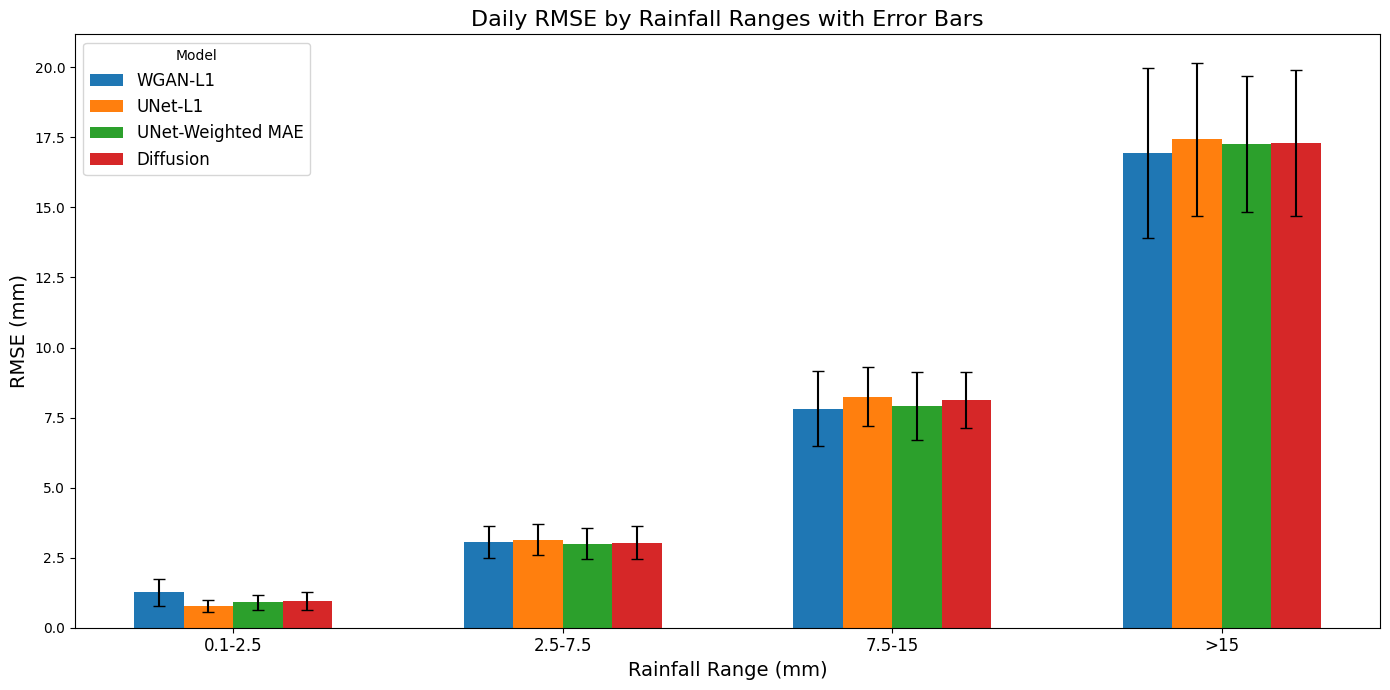

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 加载数据
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan = ds_wgan['fcst']
hr_wgan = ds_wgan['hr']

ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet = ds_unet['fcst']
hr_unet = ds_unet['hr']

ds_unet_wmae = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_3_onestep_weightmae_aheadtop_10_addprecipnorm_15_6_60_120/prcp_downs_unet_year_2020.nc")
fcst_unet_wmae = ds_unet_wmae['fcst']
hr_unet_wmae = ds_unet_wmae['hr']

# 加载 Diffusion 模型数据
ds_diffusion = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex61_onestepdiffusion_dividemax_minmaxnormlazie_timesteps250_l2_droptop_0.5_150epoch/corrected_prcp_downs_global.nc")
fcst_diffusion = ds_diffusion['fcst_corrected']
hr_diffusion = ds_diffusion['hr']

# 定义降水区间
grade_ranges = [(0.1, 2.5), (2.5, 7.5), (7.5, 15), (15, np.inf)]

# 按降水区间计算每日 RMSE
def calculate_daily_rmse_by_ranges(fcst, hr, grade_ranges):
    rmse_dict = {f"{low}-{high}" if high != np.inf else f">{low}": [] for low, high in grade_ranges}
    fcst_grouped = fcst.groupby('time.date')
    hr_grouped = hr.groupby('time.date')

    for day in fcst_grouped.groups:
        fcst_data = fcst_grouped[day].values.reshape(-1)
        hr_data = hr_grouped[day].values.reshape(-1)
        
        for low, high in grade_ranges:
            mask = (hr_data >= low) & (hr_data < high)
            if np.any(mask):
                rmse = np.sqrt(np.mean((fcst_data[mask] - hr_data[mask]) ** 2))
            else:
                rmse = np.nan
            rmse_dict[f"{low}-{high}" if high != np.inf else f">{low}"].append(rmse)
    
    return rmse_dict

# 计算 RMSE
rmse_fcst_wgan = calculate_daily_rmse_by_ranges(fcst_wgan, hr_wgan, grade_ranges)
rmse_fcst_unet = calculate_daily_rmse_by_ranges(fcst_unet, hr_unet, grade_ranges)
rmse_fcst_unet_wmae = calculate_daily_rmse_by_ranges(fcst_unet_wmae, hr_unet_wmae, grade_ranges)
rmse_fcst_diffusion = calculate_daily_rmse_by_ranges(fcst_diffusion, hr_diffusion, grade_ranges)

# 转换为均值和标准差
def calculate_mean_std(rmse_dict):
    mean_std_dict = {}
    for key, values in rmse_dict.items():
        mean_std_dict[key] = {
            'mean': np.nanmean(values),
            'std': np.nanstd(values)
        }
    return mean_std_dict

mean_std_wgan = calculate_mean_std(rmse_fcst_wgan)
mean_std_unet = calculate_mean_std(rmse_fcst_unet)
mean_std_unet_wmae = calculate_mean_std(rmse_fcst_unet_wmae)
mean_std_diffusion = calculate_mean_std(rmse_fcst_diffusion)

# 转换为 DataFrame
thresholds = list(mean_std_wgan.keys())
models = ['WGAN-L1', 'UNet-L1', 'UNet-Weighted MAE', 'Diffusion']

mean_df = pd.DataFrame({
    'Threshold': thresholds,
    'WGAN-L1': [mean_std_wgan[t]['mean'] for t in thresholds],
    'UNet-L1': [mean_std_unet[t]['mean'] for t in thresholds],
    'UNet-Weighted MAE': [mean_std_unet_wmae[t]['mean'] for t in thresholds],
    'Diffusion': [mean_std_diffusion[t]['mean'] for t in thresholds]
})

std_df = pd.DataFrame({
    'Threshold': thresholds,
    'WGAN-L1': [mean_std_wgan[t]['std'] for t in thresholds],
    'UNet-L1': [mean_std_unet[t]['std'] for t in thresholds],
    'UNet-Weighted MAE': [mean_std_unet_wmae[t]['std'] for t in thresholds],
    'Diffusion': [mean_std_diffusion[t]['std'] for t in thresholds]
})

# 绘制柱状图
bar_width = 0.15
x = np.arange(len(thresholds))  # Threshold位置

plt.figure(figsize=(14, 7))

for i, model in enumerate(models):
    plt.bar(x + i * bar_width, mean_df[model], width=bar_width, yerr=std_df[model], label=model, capsize=4)

plt.xticks(x + bar_width * 1.5, thresholds, fontsize=12)
plt.xlabel('Rainfall Range (mm)', fontsize=14)
plt.ylabel('RMSE (mm)', fontsize=14)
plt.title('Daily RMSE by Rainfall Ranges with Error Bars', fontsize=16)
plt.legend(title='Model', fontsize=12, loc='upper left')
plt.tight_layout()
plt.grid(False)
plt.tick_params(axis='x', which='both', bottom=True, top=False)
plt.tick_params(axis='y', which='both', left=True, right=False)
plt.show()


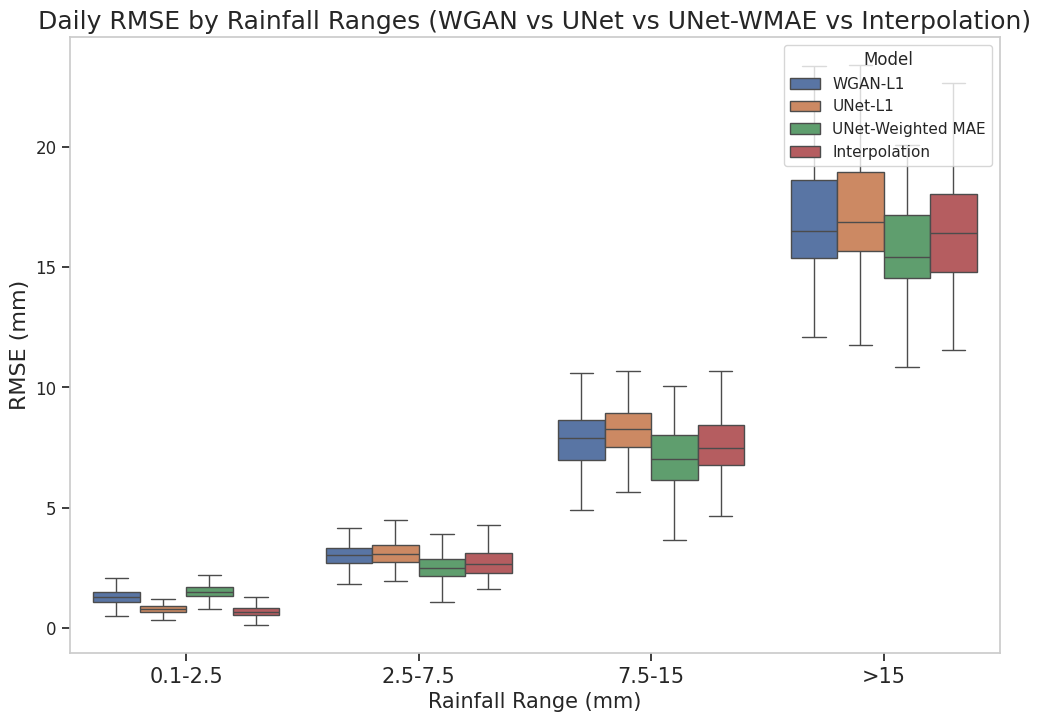

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 加载 WGAN-L1 数据集
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan = ds_wgan['fcst']
hr_wgan = ds_wgan['hr']
inter = ds_wgan['inter']

# 加载 UNet-L1 数据集
ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet = ds_unet['fcst']
hr_unet = ds_unet['hr']

# 加载 UNet-Weighted MAE 数据集
ds_unet_wmae = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_1_onestep_weightmae_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet_wmae = ds_unet_wmae['fcst']
hr_unet_wmae = ds_unet_wmae['hr']

# 定义降水区间（上下限）
grade_ranges = [(0.1, 2.5), (2.5, 7.5), (7.5, 15), (15, np.inf)]


# 计算按天 RMSE（按降水区间分段）
def calculate_daily_rmse_by_ranges(fcst, hr, grade_ranges):
    rmse_dict = {f"{low}-{high}" if high != np.inf else f">{low}": [] for low, high in grade_ranges}
    
    # 按天分组
    fcst_grouped = fcst.groupby('time.date')
    hr_grouped = hr.groupby('time.date')

    for day in fcst_grouped.groups:
        fcst_data = fcst_grouped[day].values.reshape(-1)
        hr_data = hr_grouped[day].values.reshape(-1)
        
        for low, high in grade_ranges:
            # 筛选出在区间 [low, high) 内的降水点
            mask = (hr_data >= low) & (hr_data < high)
            
            if np.any(mask):
                rmse = np.sqrt(np.mean((fcst_data[mask] - hr_data[mask]) ** 2))
            else:
                rmse = np.nan  # 如果无降水超过阈值，填充 NaN
            rmse_dict[f"{low}-{high}" if high != np.inf else f">{low}"].append(rmse)
    
    return rmse_dict

# 计算 WGAN、UNet 和 UNet-WMAE 的按天 RMSE
rmse_fcst_wgan = calculate_daily_rmse_by_ranges(fcst_wgan, hr_wgan, grade_ranges)
rmse_fcst_unet = calculate_daily_rmse_by_ranges(fcst_unet, hr_unet, grade_ranges)
rmse_fcst_unet_wmae = calculate_daily_rmse_by_ranges(fcst_unet_wmae, hr_unet_wmae, grade_ranges)
rmse_inter = calculate_daily_rmse_by_ranges(inter, hr_wgan, grade_ranges)

# 解决长度不一致问题
def pad_dict_to_same_length(rmse_dict):
    max_length = max(len(v) for v in rmse_dict.values())
    for k, v in rmse_dict.items():
        if len(v) < max_length:
            v.extend([np.nan] * (max_length - len(v)))
    return rmse_dict

rmse_fcst_wgan = pad_dict_to_same_length(rmse_fcst_wgan)
rmse_fcst_unet = pad_dict_to_same_length(rmse_fcst_unet)
rmse_fcst_unet_wmae = pad_dict_to_same_length(rmse_fcst_unet_wmae)
rmse_inter = pad_dict_to_same_length(rmse_inter)

# 转换为 DataFrame
df_wgan = pd.DataFrame(rmse_fcst_wgan).melt(var_name='Threshold', value_name='RMSE')
df_wgan['Type'] = 'WGAN-L1'

df_unet = pd.DataFrame(rmse_fcst_unet).melt(var_name='Threshold', value_name='RMSE')
df_unet['Type'] = 'UNet-L1'

df_unet_wmae = pd.DataFrame(rmse_fcst_unet_wmae).melt(var_name='Threshold', value_name='RMSE')
df_unet_wmae['Type'] = 'UNet-Weighted MAE'

df_inter = pd.DataFrame(rmse_inter).melt(var_name='Threshold', value_name='RMSE')
df_inter['Type'] = 'Interpolation'

df = pd.concat([df_wgan, df_unet, df_unet_wmae, df_inter])  # 合并四个结果

# 去除 NaN
df = df.dropna(subset=['RMSE'])

sns.set(style="whitegrid")

# 绘制箱线图
plt.figure(figsize=(12, 8))
sns.boxplot(x='Threshold', y='RMSE', hue='Type', data=df, showfliers=False)  # 不显示离群点

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.title('Daily RMSE by Rainfall Ranges (WGAN vs UNet vs UNet-WMAE vs Interpolation)', fontsize=18)
plt.xlabel('Rainfall Range (mm)', fontsize=15)
plt.ylabel('RMSE (mm)', fontsize=16)

plt.xticks(fontsize=15)
plt.yticks(fontsize=12)

plt.grid(False)
plt.tick_params(axis='x', which='both', bottom=True, top=False)
plt.tick_params(axis='y', which='both', left=True, right=False)

plt.legend(title='Model', loc='upper right')
plt.show()


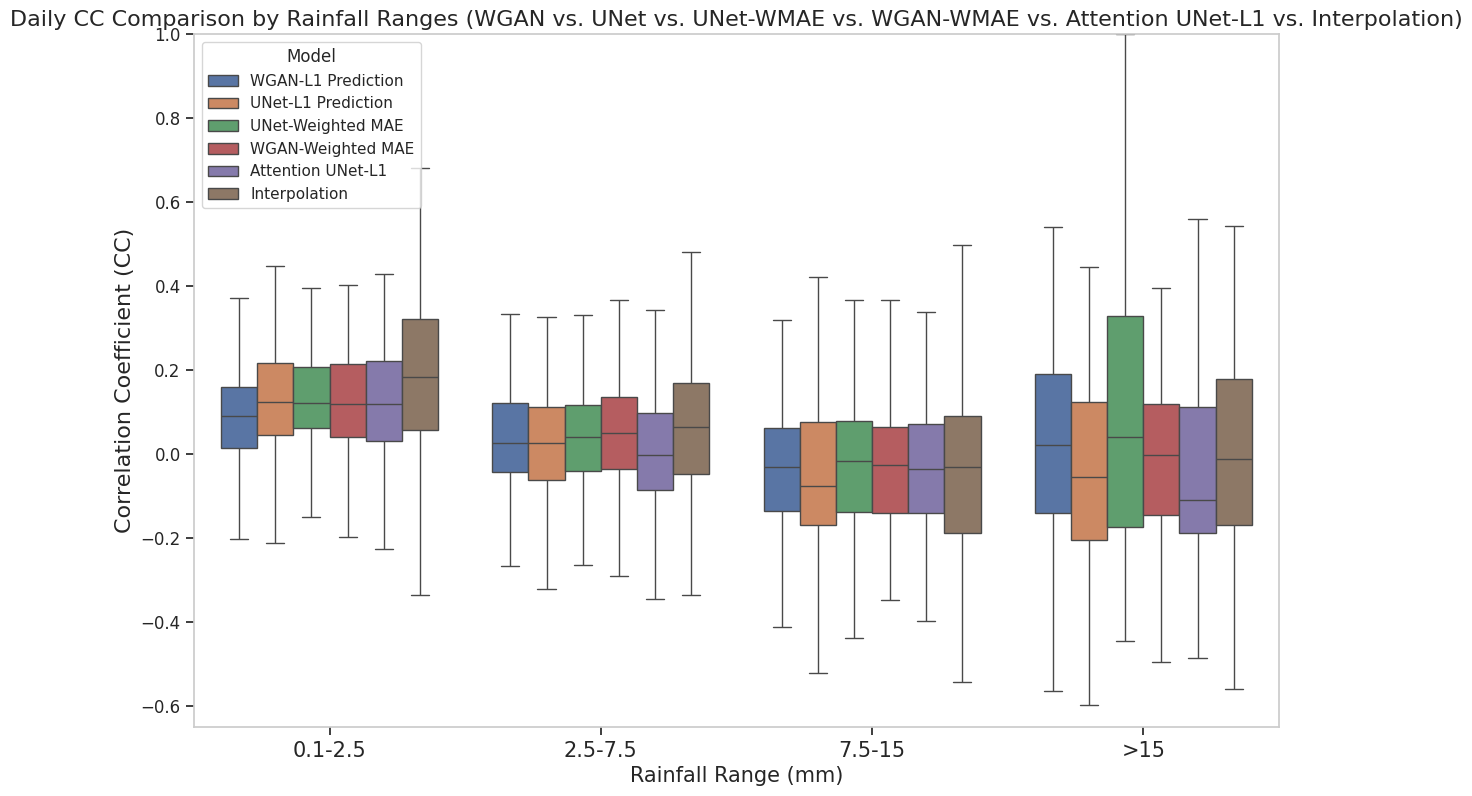

In [22]:
    import xarray as xr
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    # 加载 WGAN-L1 数据集
    ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
    fcst_wgan = ds_wgan['fcst']
    hr_wgan = ds_wgan['hr']
    inter = ds_wgan['inter']

    # 加载 UNet-L1 数据集
    ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
    fcst_unet = ds_unet['fcst']
    hr_unet = ds_unet['hr']

    # 加载 UNet-Weighted MAE 数据集
    ds_unet_wmae = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_6_onestep_weightmae_aheadtop_10_addprecipnorm_08_8_70_145/prcp_downs_unet_year_2020.nc")
    fcst_unet_wmae = ds_unet_wmae['fcst']
    hr_unet_wmae = ds_unet_wmae['hr']

    # 加载 wgan-Weighted MAE 数据集
    ds_wgan_wmae = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_0_1_onestepwgan_cri5_1000_weightmae_1.5_6_60_120_aheadtop_10_160epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
    fcst_wgan_wmae = ds_wgan_wmae['fcst']
    hr_wgan_wmae = ds_wgan_wmae['hr']

    # 加载 Attention UNet-L1 数据集
    ds_attention_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_0_1_onestep_atteintionunet_l1_aheadtop_10_addprecipnorm/prcp_downs_attention_unet_year_2020.nc")
    fcst_attention_unet = ds_attention_unet['fcst']
    hr_attention_unet = ds_attention_unet['hr']

    # 定义降水区间（上下限）
    grade_ranges = [(0.1, 2.5), (2.5, 7.5), (7.5, 15), (15, np.inf)]

    # 计算按降水区间的 CC（同一天降雨合并计算）
    def calculate_daily_cc_by_ranges(fcst, hr, grade_ranges):
        cc_dict = {f"{low}-{high}" if high != np.inf else f">{low}": [] for low, high in grade_ranges}
        
        # 按天分组
        fcst_grouped = fcst.groupby('time.date')
        hr_grouped = hr.groupby('time.date')

        # 遍历每一天
        for day in fcst_grouped.groups:
            fcst_data = fcst_grouped[day].values.reshape(-1)
            hr_data = hr_grouped[day].values.reshape(-1)
            
            for low, high in grade_ranges:
                # 筛选出在区间 [low, high) 内的降水点
                mask = (hr_data >= low) & (hr_data < high)
                
                if np.any(mask):
                    # 避免标准差为0导致的除零错误
                    if np.std(fcst_data[mask]) > 0 and np.std(hr_data[mask]) > 0:
                        cc = np.corrcoef(fcst_data[mask], hr_data[mask])[0, 1]
                    else:
                        cc = np.nan  # 如果标准差为0，返回 NaN
                else:
                    cc = np.nan  # 如果无降水超过阈值，填充 NaN
                cc_dict[f"{low}-{high}" if high != np.inf else f">{low}"].append(cc)
        
        return cc_dict


    # 计算不同模型的 CC（按天计算）
    cc_fcst_wgan = calculate_daily_cc_by_ranges(fcst_wgan, hr_wgan, grade_ranges)
    cc_fcst_unet = calculate_daily_cc_by_ranges(fcst_unet, hr_unet, grade_ranges)
    cc_fcst_unet_wmae = calculate_daily_cc_by_ranges(fcst_unet_wmae, hr_unet_wmae, grade_ranges)
    cc_fcst_wgan_wmae = calculate_daily_cc_by_ranges(fcst_wgan_wmae, hr_wgan_wmae, grade_ranges)
    cc_fcst_attention_unet = calculate_daily_cc_by_ranges(fcst_attention_unet, hr_attention_unet, grade_ranges)
    cc_inter = calculate_daily_cc_by_ranges(inter, hr_wgan, grade_ranges)

    # 解决长度不一致问题
    def pad_dict_to_same_length(cc_dict):
        max_length = max(len(v) for v in cc_dict.values())
        for k, v in cc_dict.items():
            if len(v) < max_length:
                v.extend([np.nan] * (max_length - len(v)))
        return cc_dict

    cc_fcst_wgan = pad_dict_to_same_length(cc_fcst_wgan)
    cc_fcst_unet = pad_dict_to_same_length(cc_fcst_unet)
    cc_fcst_unet_wmae = pad_dict_to_same_length(cc_fcst_unet_wmae)
    cc_fcst_wgan_wmae = pad_dict_to_same_length(cc_fcst_wgan_wmae)
    cc_fcst_attention_unet = pad_dict_to_same_length(cc_fcst_attention_unet)
    cc_inter = pad_dict_to_same_length(cc_inter)

    # 转换为 DataFrame
    df_wgan = pd.DataFrame(cc_fcst_wgan).melt(var_name='Threshold', value_name='CC')
    df_wgan['Type'] = 'WGAN-L1 Prediction'

    df_unet = pd.DataFrame(cc_fcst_unet).melt(var_name='Threshold', value_name='CC')
    df_unet['Type'] = 'UNet-L1 Prediction'

    df_unet_wmae = pd.DataFrame(cc_fcst_unet_wmae).melt(var_name='Threshold', value_name='CC')
    df_unet_wmae['Type'] = 'UNet-Weighted MAE'

    df_wgan_wmae = pd.DataFrame(cc_fcst_wgan_wmae).melt(var_name='Threshold', value_name='CC')
    df_wgan_wmae['Type'] = 'WGAN-Weighted MAE'

    df_attention_unet = pd.DataFrame(cc_fcst_attention_unet).melt(var_name='Threshold', value_name='CC')
    df_attention_unet['Type'] = 'Attention UNet-L1'

    df_inter = pd.DataFrame(cc_inter).melt(var_name='Threshold', value_name='CC')
    df_inter['Type'] = 'Interpolation'

    # 合并数据
    df = pd.concat([df_wgan, df_unet, df_unet_wmae, df_wgan_wmae, df_attention_unet, df_inter])

    # 去除 NaN
    df = df.dropna(subset=['CC'])

    # 设置绘图风格
    sns.set(style="whitegrid")

    # 绘制箱线图
    plt.figure(figsize=(14, 9))
    sns.boxplot(x='Threshold', y='CC', hue='Type', data=df,
                showfliers=False)  # 不显示离群点

    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.title('Daily CC Comparison by Rainfall Ranges (WGAN vs. UNet vs. UNet-WMAE vs. WGAN-WMAE vs. Attention UNet-L1 vs. Interpolation)', fontsize=16)
    plt.xlabel('Rainfall Range (mm)', fontsize=15)
    plt.ylabel('Correlation Coefficient (CC)', fontsize=16)
    plt.ylim(-0.65, 1)  

    plt.xticks(fontsize=15)
    plt.yticks(fontsize=12)

    plt.grid(False)
    plt.tick_params(axis='x', which='both', bottom=True)
    plt.tick_params(axis='y', which='both', left=True)

    plt.legend(title='Model', loc='upper left')
    plt.show()


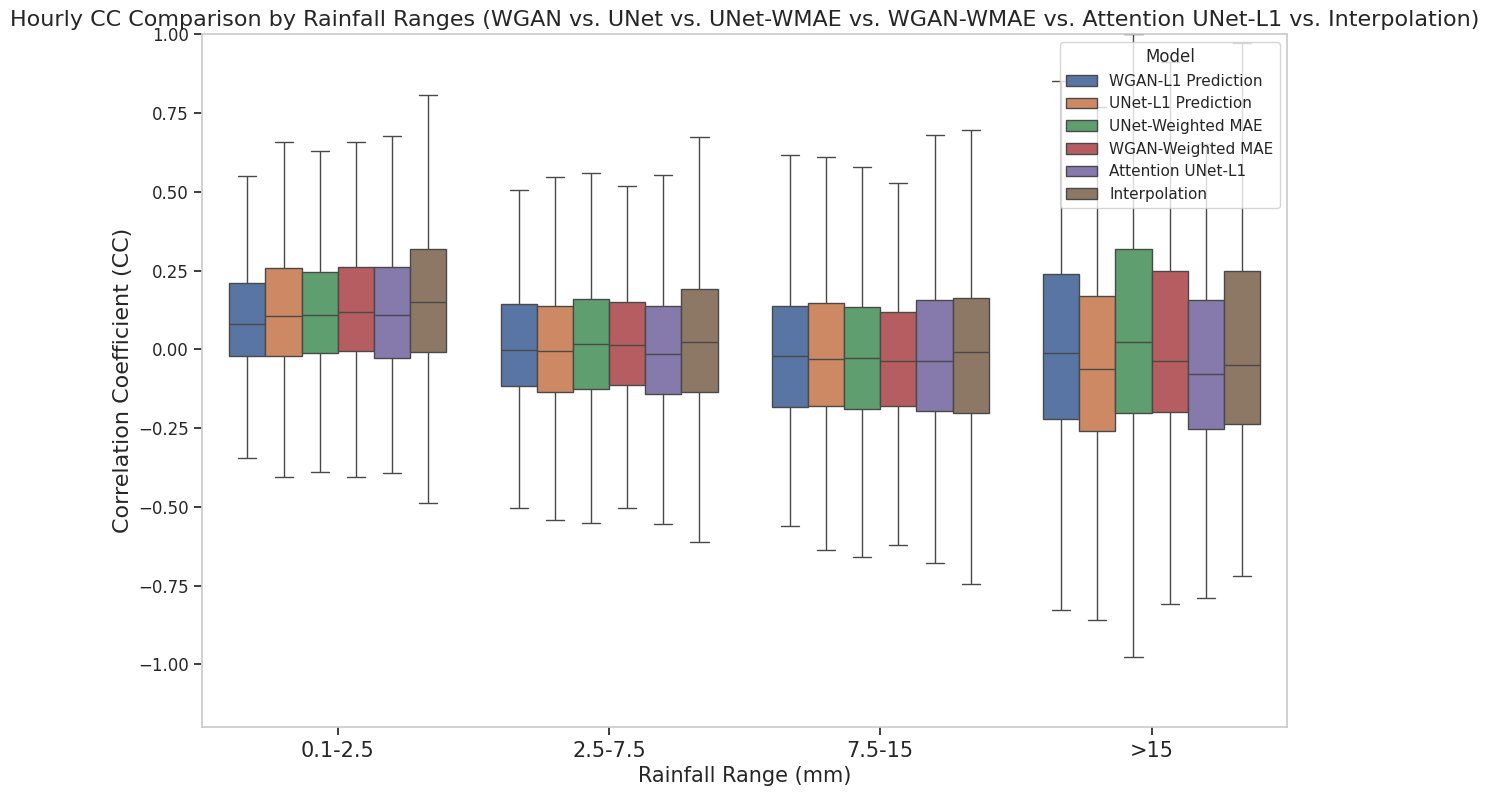

In [23]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 加载 WGAN-L1 数据集
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan = ds_wgan['fcst']
hr_wgan = ds_wgan['hr']
inter = ds_wgan['inter']

# 加载 UNet-L1 数据集
ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet = ds_unet['fcst']
hr_unet = ds_unet['hr']

# 加载 UNet-Weighted MAE 数据集
ds_unet_wmae = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_6_onestep_weightmae_aheadtop_10_addprecipnorm_08_8_70_145/prcp_downs_unet_year_2020.nc")
fcst_unet_wmae = ds_unet_wmae['fcst']
hr_unet_wmae = ds_unet_wmae['hr']

# 加载 wgan-Weighted MAE 数据集
ds_wgan_wmae = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_0_1_onestepwgan_cri5_1000_weightmae_1.5_6_60_120_aheadtop_10_160epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan_wmae = ds_wgan_wmae['fcst']
hr_wgan_wmae = ds_wgan_wmae['hr']

# 加载 Attention UNet-L1 数据集
ds_attention_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_0_1_onestep_atteintionunet_l1_aheadtop_10_addprecipnorm/prcp_downs_attention_unet_year_2020.nc")
fcst_attention_unet = ds_attention_unet['fcst']
hr_attention_unet = ds_attention_unet['hr']

# 定义降水区间（上下限）
grade_ranges = [(0.1, 2.5), (2.5, 7.5), (7.5, 15), (15, np.inf)]

# 计算按降水区间的 CC（同一天同时间点的所有降水整合在一起）
def calculate_daily_cc_by_ranges(fcst, hr, grade_ranges):
    cc_dict = {f"{low}-{high}" if high != np.inf else f">{low}": [] for low, high in grade_ranges}
    
    # 创建 DataArray 来提取日期和小时信息
    time_dates = fcst['time'].dt.date
    time_hours = fcst['time'].dt.hour

    # 创建一个新的 DataArray，作为索引将时间与小时合并
    time_combined = xr.DataArray(
        [f"{date}_{hour}" for date, hour in zip(time_dates.values, time_hours.values)],
        coords=[fcst['time']],
        dims=["time"],
        name="time_combined"
    )

    # 按天和时间分组
    fcst_grouped = fcst.groupby(time_combined)
    hr_grouped = hr.groupby(time_combined)

    # 遍历每一天和每个时间点
    for time_idx in fcst_grouped.groups:
        fcst_data = fcst_grouped[time_idx].values.flatten()  # 将该时间点的所有空间降水数据展平
        hr_data = hr_grouped[time_idx].values.flatten()  # 展平目标高分辨率数据
        
        for low, high in grade_ranges:
            mask = (hr_data >= low) & (hr_data < high)
            if np.any(mask):
                # 计算相关系数（CC）
                if np.std(fcst_data[mask]) > 0 and np.std(hr_data[mask]) > 0:
                    cc = np.corrcoef(fcst_data[mask], hr_data[mask])[0, 1]
                else:
                    cc = np.nan  # 如果标准差为0，返回 NaN
            else:
                cc = np.nan  # 如果无降水超过阈值，填充 NaN
            cc_dict[f"{low}-{high}" if high != np.inf else f">{low}"].append(cc)
    
    return cc_dict


# 计算不同模型的 CC（按天计算）
cc_fcst_wgan = calculate_daily_cc_by_ranges(fcst_wgan, hr_wgan, grade_ranges)
cc_fcst_unet = calculate_daily_cc_by_ranges(fcst_unet, hr_unet, grade_ranges)
cc_fcst_unet_wmae = calculate_daily_cc_by_ranges(fcst_unet_wmae, hr_unet_wmae, grade_ranges)
cc_fcst_wgan_wmae = calculate_daily_cc_by_ranges(fcst_wgan_wmae, hr_wgan_wmae, grade_ranges)
cc_fcst_attention_unet = calculate_daily_cc_by_ranges(fcst_attention_unet, hr_attention_unet, grade_ranges)
cc_inter = calculate_daily_cc_by_ranges(inter, hr_wgan, grade_ranges)

# 解决长度不一致问题
def pad_dict_to_same_length(cc_dict):
    max_length = max(len(v) for v in cc_dict.values())
    for k, v in cc_dict.items():
        if len(v) < max_length:
            v.extend([np.nan] * (max_length - len(v)))
    return cc_dict

cc_fcst_wgan = pad_dict_to_same_length(cc_fcst_wgan)
cc_fcst_unet = pad_dict_to_same_length(cc_fcst_unet)
cc_fcst_unet_wmae = pad_dict_to_same_length(cc_fcst_unet_wmae)
cc_fcst_wgan_wmae = pad_dict_to_same_length(cc_fcst_wgan_wmae)
cc_fcst_attention_unet = pad_dict_to_same_length(cc_fcst_attention_unet)
cc_inter = pad_dict_to_same_length(cc_inter)

# 转换为 DataFrame
df_wgan = pd.DataFrame(cc_fcst_wgan).melt(var_name='Threshold', value_name='CC')
df_wgan['Type'] = 'WGAN-L1 Prediction'

df_unet = pd.DataFrame(cc_fcst_unet).melt(var_name='Threshold', value_name='CC')
df_unet['Type'] = 'UNet-L1 Prediction'

df_unet_wmae = pd.DataFrame(cc_fcst_unet_wmae).melt(var_name='Threshold', value_name='CC')
df_unet_wmae['Type'] = 'UNet-Weighted MAE'

df_wgan_wmae = pd.DataFrame(cc_fcst_wgan_wmae).melt(var_name='Threshold', value_name='CC')
df_wgan_wmae['Type'] = 'WGAN-Weighted MAE'

df_attention_unet = pd.DataFrame(cc_fcst_attention_unet).melt(var_name='Threshold', value_name='CC')
df_attention_unet['Type'] = 'Attention UNet-L1'

df_inter = pd.DataFrame(cc_inter).melt(var_name='Threshold', value_name='CC')
df_inter['Type'] = 'Interpolation'

# 合并数据
df = pd.concat([df_wgan, df_unet, df_unet_wmae, df_wgan_wmae, df_attention_unet, df_inter])

# 去除 NaN
df = df.dropna(subset=['CC'])

# 设置绘图风格
sns.set(style="whitegrid")

# 绘制箱线图
plt.figure(figsize=(14, 9))
sns.boxplot(x='Threshold', y='CC', hue='Type', data=df,
            showfliers=False)  # 不显示离群点

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.title('Hourly CC Comparison by Rainfall Ranges (WGAN vs. UNet vs. UNet-WMAE vs. WGAN-WMAE vs. Attention UNet-L1 vs. Interpolation)', fontsize=16)
plt.xlabel('Rainfall Range (mm)', fontsize=15)
plt.ylabel('Correlation Coefficient (CC)', fontsize=16)
plt.ylim(-1.2, 1)  

plt.xticks(fontsize=15)
plt.yticks(fontsize=12)

plt.grid(False)
plt.tick_params(axis='x', which='both', bottom=True)
plt.tick_params(axis='y', which='both', left=True)

plt.legend(title='Model', loc='upper right')
plt.show()


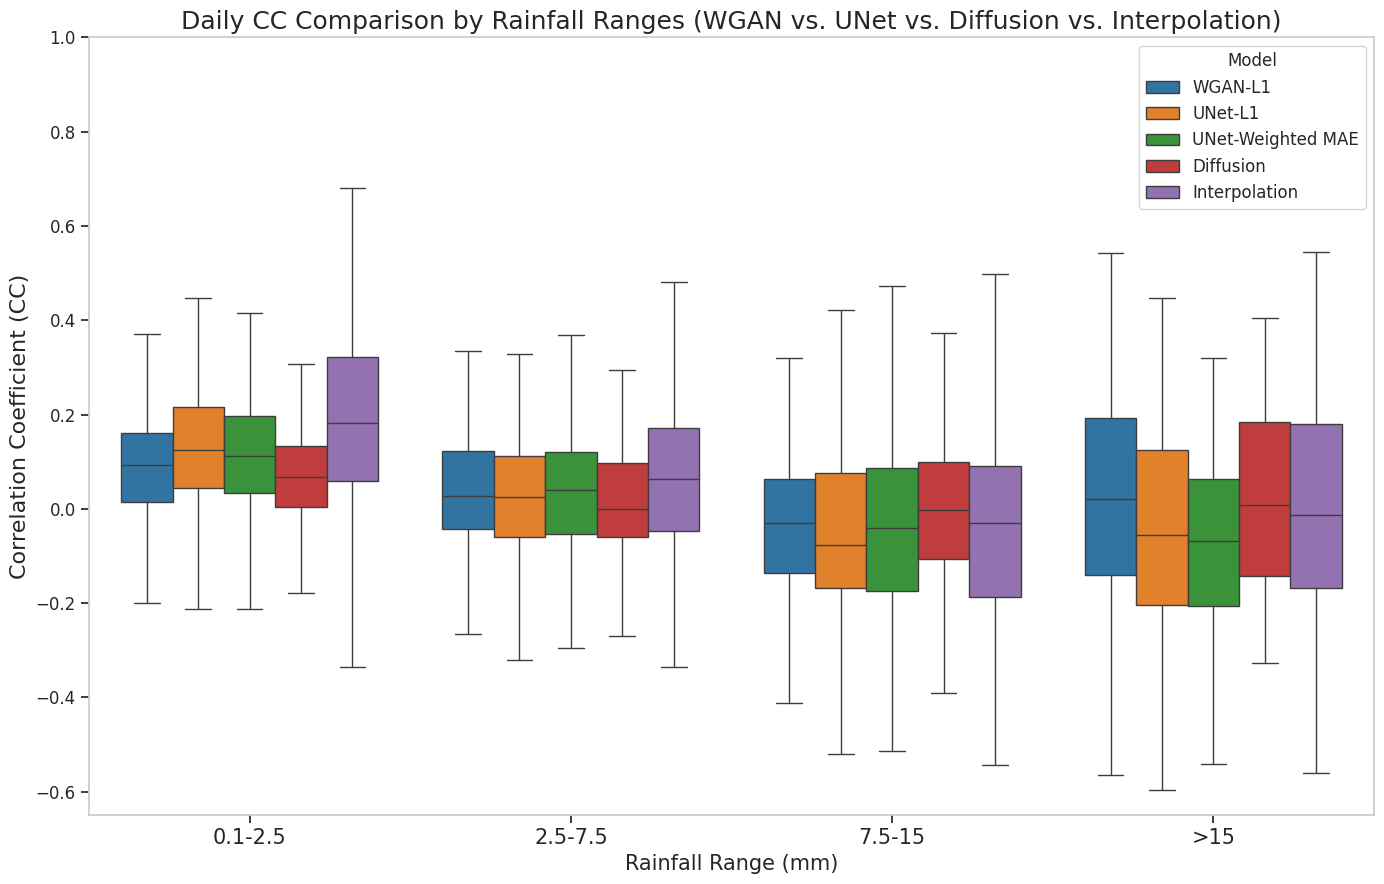

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据集
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan = ds_wgan['fcst']
hr_wgan = ds_wgan['hr']
inter = ds_wgan['inter']

ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet = ds_unet['fcst']
hr_unet = ds_unet['hr']

ds_unet_wmae = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_3_onestep_weightmae_aheadtop_10_addprecipnorm_15_6_60_120/prcp_downs_unet_year_2020.nc")
fcst_unet_wmae = ds_unet_wmae['fcst']
hr_unet_wmae = ds_unet_wmae['hr']

# 加载 Diffusion 数据集
ds_diffusion = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex61_onestepdiffusion_dividemax_minmaxnormlazie_timesteps250_l2_droptop_0.5_150epoch/corrected_prcp_downs_global.nc")
fcst_diffusion = ds_diffusion['fcst_corrected']
hr_diffusion = ds_diffusion['hr']

# 定义降水区间（上下限）
grade_ranges = [(0.1, 2.5), (2.5, 7.5), (7.5, 15), (15, np.inf)]

# 计算按降水区间的 CC（同一天降雨合并计算）
def calculate_daily_cc_by_ranges(fcst, hr, grade_ranges):
    cc_dict = {f"{low}-{high}" if high != np.inf else f">{low}": [] for low, high in grade_ranges}
    
    # 按天分组
    fcst_grouped = fcst.groupby('time.date')
    hr_grouped = hr.groupby('time.date')

    # 遍历每一天
    for day in fcst_grouped.groups:
        fcst_data = fcst_grouped[day].values.reshape(-1)
        hr_data = hr_grouped[day].values.reshape(-1)
        
        for low, high in grade_ranges:
            # 筛选出在区间 [low, high) 内的降水点
            mask = (hr_data >= low) & (hr_data < high)
            
            if np.any(mask):
                # 避免标准差为0导致的除零错误
                if np.std(fcst_data[mask]) > 0 and np.std(hr_data[mask]) > 0:
                    cc = np.corrcoef(fcst_data[mask], hr_data[mask])[0, 1]
                else:
                    cc = np.nan  # 如果标准差为0，返回 NaN
            else:
                cc = np.nan  # 如果无降水超过阈值，填充 NaN
            cc_dict[f"{low}-{high}" if high != np.inf else f">{low}"].append(cc)
    
    return cc_dict

# 计算不同模型的 CC（按天计算）
cc_fcst_wgan = calculate_daily_cc_by_ranges(fcst_wgan, hr_wgan, grade_ranges)
cc_fcst_unet = calculate_daily_cc_by_ranges(fcst_unet, hr_unet, grade_ranges)
cc_fcst_unet_wmae = calculate_daily_cc_by_ranges(fcst_unet_wmae, hr_unet_wmae, grade_ranges)
cc_fcst_diffusion = calculate_daily_cc_by_ranges(fcst_diffusion, hr_diffusion, grade_ranges)
cc_inter = calculate_daily_cc_by_ranges(inter, hr_wgan, grade_ranges)

# 解决长度不一致问题
def pad_dict_to_same_length(cc_dict):
    max_length = max(len(v) for v in cc_dict.values())
    for k, v in cc_dict.items():
        if len(v) < max_length:
            v.extend([np.nan] * (max_length - len(v)))
    return cc_dict

cc_fcst_wgan = pad_dict_to_same_length(cc_fcst_wgan)
cc_fcst_unet = pad_dict_to_same_length(cc_fcst_unet)
cc_fcst_unet_wmae = pad_dict_to_same_length(cc_fcst_unet_wmae)
cc_fcst_diffusion = pad_dict_to_same_length(cc_fcst_diffusion)
cc_inter = pad_dict_to_same_length(cc_inter)

# 转换为 DataFrame
df_wgan = pd.DataFrame(cc_fcst_wgan).melt(var_name='Threshold', value_name='CC')
df_wgan['Type'] = 'WGAN-L1'

df_unet = pd.DataFrame(cc_fcst_unet).melt(var_name='Threshold', value_name='CC')
df_unet['Type'] = 'UNet-L1'

df_unet_wmae = pd.DataFrame(cc_fcst_unet_wmae).melt(var_name='Threshold', value_name='CC')
df_unet_wmae['Type'] = 'UNet-Weighted MAE'

df_diffusion = pd.DataFrame(cc_fcst_diffusion).melt(var_name='Threshold', value_name='CC')
df_diffusion['Type'] = 'Diffusion'

df_inter = pd.DataFrame(cc_inter).melt(var_name='Threshold', value_name='CC')
df_inter['Type'] = 'Interpolation'

# 合并数据
df = pd.concat([df_wgan, df_unet, df_unet_wmae, df_diffusion, df_inter])

# 去除 NaN
df = df.dropna(subset=['CC'])

# 设置绘图风格
sns.set(style="whitegrid")

# 绘制箱线图，使用与 RMSE 图一致的颜色
plt.figure(figsize=(14, 9))
sns.boxplot(x='Threshold', y='CC', hue='Type', data=df,
            palette={'WGAN-L1': 'tab:blue',
                     'UNet-L1': 'tab:orange',
                     'UNet-Weighted MAE': 'tab:green',
                     'Diffusion': 'tab:red',
                     'Interpolation': 'tab:purple'},
            showfliers=False)  # 不显示离群点

plt.title('Daily CC Comparison by Rainfall Ranges (WGAN vs. UNet vs. Diffusion vs. Interpolation)', fontsize=18)
plt.xlabel('Rainfall Range (mm)', fontsize=15)
plt.ylabel('Correlation Coefficient (CC)', fontsize=16)
plt.ylim(-0.65, 1)

plt.xticks(fontsize=15)
plt.yticks(fontsize=12)
plt.grid(False)
plt.tick_params(axis='x', which='both', bottom=True)
plt.tick_params(axis='y', which='both', left=True)
plt.legend(title='Model', fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()


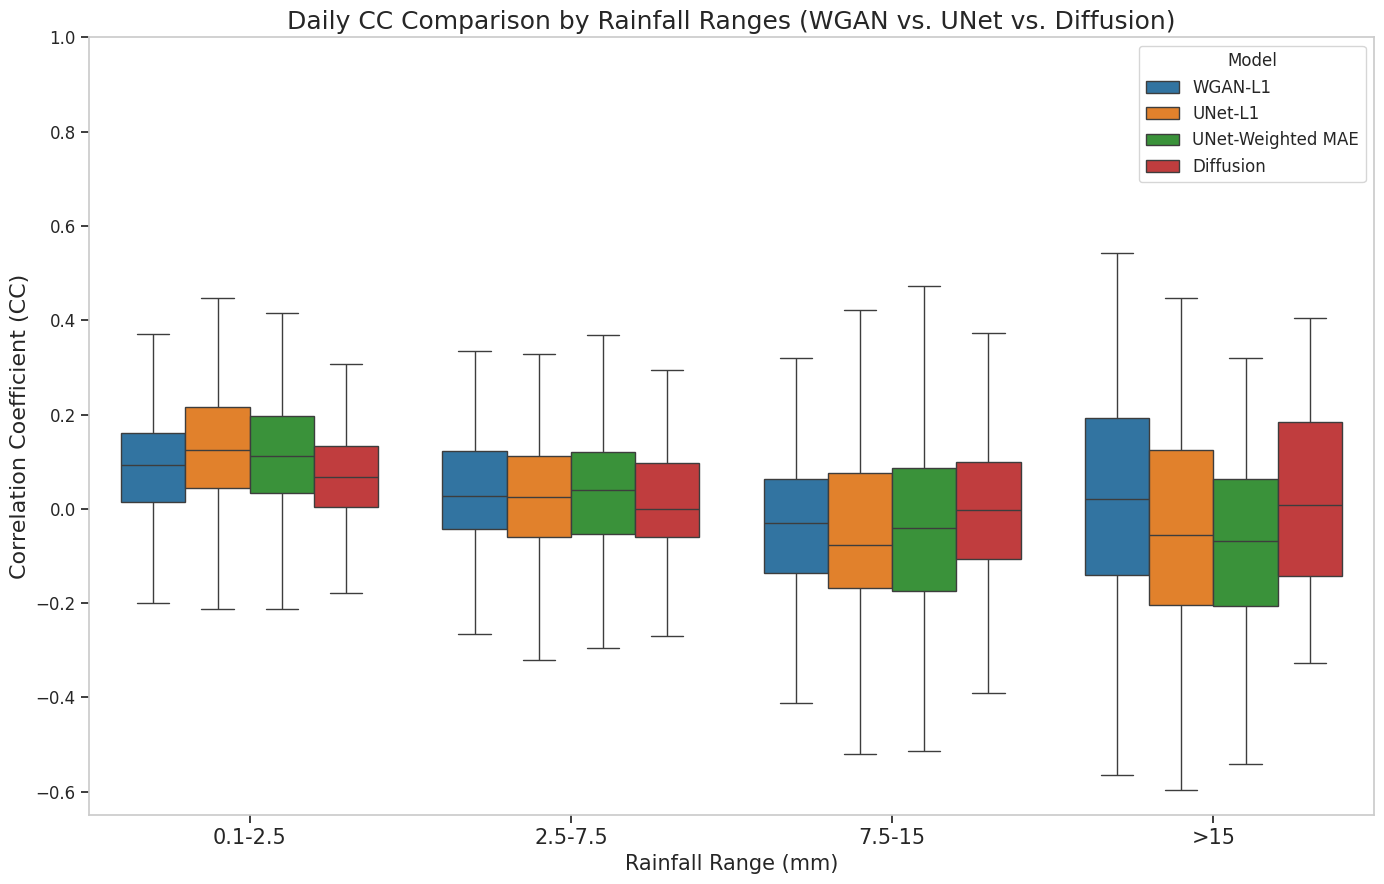

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据集
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan = ds_wgan['fcst']
hr_wgan = ds_wgan['hr']

ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet = ds_unet['fcst']
hr_unet = ds_unet['hr']

ds_unet_wmae = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_3_onestep_weightmae_aheadtop_10_addprecipnorm_15_6_60_120/prcp_downs_unet_year_2020.nc")
fcst_unet_wmae = ds_unet_wmae['fcst']
hr_unet_wmae = ds_unet_wmae['hr']

# 加载 Diffusion 数据集
ds_diffusion = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex61_onestepdiffusion_dividemax_minmaxnormlazie_timesteps250_l2_droptop_0.5_150epoch/corrected_prcp_downs_global.nc")
fcst_diffusion = ds_diffusion['fcst_corrected']
hr_diffusion = ds_diffusion['hr']

# 定义降水区间（上下限）
grade_ranges = [(0.1, 2.5), (2.5, 7.5), (7.5, 15), (15, np.inf)]

# 计算按降水区间的 CC（同一天降雨合并计算）
def calculate_daily_cc_by_ranges(fcst, hr, grade_ranges):
    cc_dict = {f"{low}-{high}" if high != np.inf else f">{low}": [] for low, high in grade_ranges}
    fcst_grouped = fcst.groupby('time.date')
    hr_grouped = hr.groupby('time.date')

    for day in fcst_grouped.groups:
        fcst_data = fcst_grouped[day].values.reshape(-1)
        hr_data = hr_grouped[day].values.reshape(-1)
        
        for low, high in grade_ranges:
            mask = (hr_data >= low) & (hr_data < high)
            if np.any(mask):
                if np.std(fcst_data[mask]) > 0 and np.std(hr_data[mask]) > 0:
                    cc = np.corrcoef(fcst_data[mask], hr_data[mask])[0, 1]
                else:
                    cc = np.nan  # 如果标准差为0，返回 NaN
            else:
                cc = np.nan  # 如果无降水超过阈值，填充 NaN
            cc_dict[f"{low}-{high}" if high != np.inf else f">{low}"].append(cc)
    return cc_dict

# 计算不同模型的 CC（按天计算）
cc_fcst_wgan = calculate_daily_cc_by_ranges(fcst_wgan, hr_wgan, grade_ranges)
cc_fcst_unet = calculate_daily_cc_by_ranges(fcst_unet, hr_unet, grade_ranges)
cc_fcst_unet_wmae = calculate_daily_cc_by_ranges(fcst_unet_wmae, hr_unet_wmae, grade_ranges)
cc_fcst_diffusion = calculate_daily_cc_by_ranges(fcst_diffusion, hr_diffusion, grade_ranges)

# 解决长度不一致问题
def pad_dict_to_same_length(cc_dict):
    max_length = max(len(v) for v in cc_dict.values())
    for k, v in cc_dict.items():
        if len(v) < max_length:
            v.extend([np.nan] * (max_length - len(v)))
    return cc_dict

cc_fcst_wgan = pad_dict_to_same_length(cc_fcst_wgan)
cc_fcst_unet = pad_dict_to_same_length(cc_fcst_unet)
cc_fcst_unet_wmae = pad_dict_to_same_length(cc_fcst_unet_wmae)
cc_fcst_diffusion = pad_dict_to_same_length(cc_fcst_diffusion)

# 转换为 DataFrame
df_wgan = pd.DataFrame(cc_fcst_wgan).melt(var_name='Threshold', value_name='CC')
df_wgan['Type'] = 'WGAN-L1'

df_unet = pd.DataFrame(cc_fcst_unet).melt(var_name='Threshold', value_name='CC')
df_unet['Type'] = 'UNet-L1'

df_unet_wmae = pd.DataFrame(cc_fcst_unet_wmae).melt(var_name='Threshold', value_name='CC')
df_unet_wmae['Type'] = 'UNet-Weighted MAE'

df_diffusion = pd.DataFrame(cc_fcst_diffusion).melt(var_name='Threshold', value_name='CC')
df_diffusion['Type'] = 'Diffusion'

# 合并数据
df = pd.concat([df_wgan, df_unet, df_unet_wmae, df_diffusion])

# 去除 NaN
df = df.dropna(subset=['CC'])

# 设置绘图风格
sns.set(style="whitegrid")

# 绘制箱线图，使用与 RMSE 图一致的颜色
plt.figure(figsize=(14, 9))
sns.boxplot(x='Threshold', y='CC', hue='Type', data=df,
            palette={'WGAN-L1': 'tab:blue',
                     'UNet-L1': 'tab:orange',
                     'UNet-Weighted MAE': 'tab:green',
                     'Diffusion': 'tab:red'},
            showfliers=False)  # 不显示离群点

plt.title('Daily CC Comparison by Rainfall Ranges (WGAN vs. UNet vs. Diffusion)', fontsize=18)
plt.xlabel('Rainfall Range (mm)', fontsize=15)
plt.ylabel('Correlation Coefficient (CC)', fontsize=16)
plt.ylim(-0.65, 1)

plt.xticks(fontsize=15)
plt.yticks(fontsize=12)
plt.grid(False)
plt.tick_params(axis='x', which='both', bottom=True)
plt.tick_params(axis='y', which='both', left=True)
plt.legend(title='Model', fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()


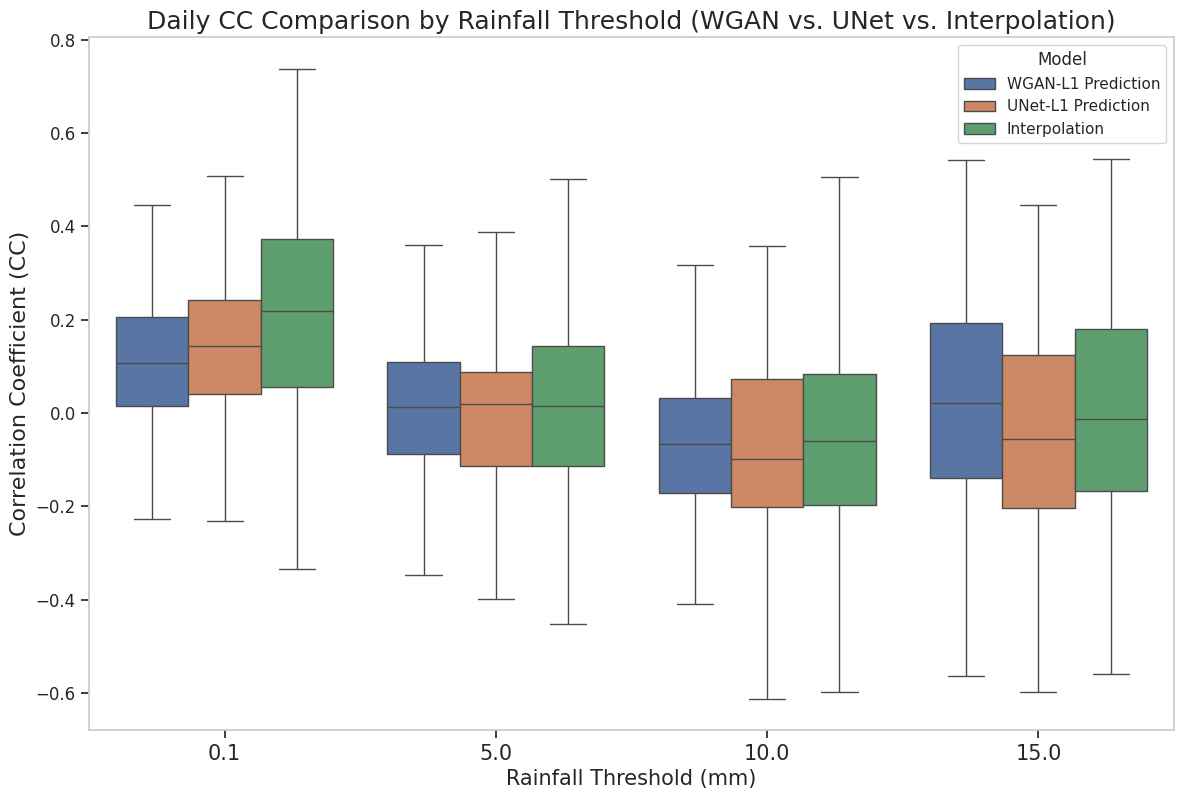

In [28]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 降水强度阈值列表
grade_list = [0.1, 5, 10, 15]

# 计算按降水强度的 CC（同一天降雨合并计算）
def calculate_daily_cc_by_threshold(fcst, hr, grade_list):
    cc_dict = {grade: [] for grade in grade_list}  
    
    # 直接在 xarray 数据中按日期分组
    fcst_grouped = fcst.groupby('time.date')
    hr_grouped = hr.groupby('time.date')

    for day in fcst_grouped.groups:
        fcst_data = fcst_grouped[day].values.reshape(-1)
        hr_data = hr_grouped[day].values.reshape(-1)
        
        for grade in grade_list:
            # 只计算超过阈值的降水点的 CC
            mask = hr_data >= grade
            if np.any(mask):
                # 避免标准差为0导致的除零错误
                if np.std(fcst_data[mask]) > 0 and np.std(hr_data[mask]) > 0:
                    cc = np.corrcoef(fcst_data[mask], hr_data[mask])[0, 1]
                else:
                    cc = np.nan  # 如果标准差为0，返回 NaN
            else:
                cc = np.nan  # 如果无降水超过阈值，填充 NaN
            cc_dict[grade].append(cc)
    
    return cc_dict


# 加载 WGAN-L1 数据集
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan = ds_wgan['fcst']
hr_wgan = ds_wgan['hr']
inter = ds_wgan['inter']

# 加载 UNet-L1 数据集
ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet = ds_unet['fcst']
hr_unet = ds_unet['hr']

# 计算不同模型的 CC（按天计算）
cc_fcst_wgan = calculate_daily_cc_by_threshold(fcst_wgan, hr_wgan, grade_list)
cc_fcst_unet = calculate_daily_cc_by_threshold(fcst_unet, hr_unet, grade_list)
cc_inter = calculate_daily_cc_by_threshold(inter, hr_wgan, grade_list)

# 解决长度不一致问题
def pad_dict_to_same_length(cc_dict):
    max_length = max(len(v) for v in cc_dict.values())
    for k, v in cc_dict.items():
        if len(v) < max_length:
            v.extend([np.nan] * (max_length - len(v)))
    return cc_dict

cc_fcst_wgan = pad_dict_to_same_length(cc_fcst_wgan)
cc_fcst_unet = pad_dict_to_same_length(cc_fcst_unet)
cc_inter = pad_dict_to_same_length(cc_inter)

# 转换为 DataFrame
df_wgan = pd.DataFrame(cc_fcst_wgan).melt(var_name='Threshold', value_name='CC')
df_wgan['Type'] = 'WGAN-L1 Prediction'

df_unet = pd.DataFrame(cc_fcst_unet).melt(var_name='Threshold', value_name='CC')
df_unet['Type'] = 'UNet-L1 Prediction'

df_inter = pd.DataFrame(cc_inter).melt(var_name='Threshold', value_name='CC')
df_inter['Type'] = 'Interpolation'

# 合并数据
df = pd.concat([df_wgan, df_unet, df_inter])

# 去除 NaN
df = df.dropna(subset=['CC'])

# 设置绘图风格
sns.set(style="whitegrid")

# 绘制箱线图
plt.figure(figsize=(14, 9))
sns.boxplot(x='Threshold', y='CC', hue='Type', data=df,
            showfliers=False)  # 不显示离群点

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.title('Daily CC Comparison by Rainfall Threshold (WGAN vs. UNet vs. Interpolation)', fontsize=18)
plt.xlabel('Rainfall Threshold (mm)', fontsize=15)
plt.ylabel('Correlation Coefficient (CC)', fontsize=16)

plt.xticks(fontsize=15)
plt.yticks(fontsize=12)

plt.grid(False)
plt.tick_params(axis='x', which='both', bottom=True)
plt.tick_params(axis='y', which='both', left=True)

plt.legend(title='Model', loc='upper right')
plt.show()


## 需要老师check

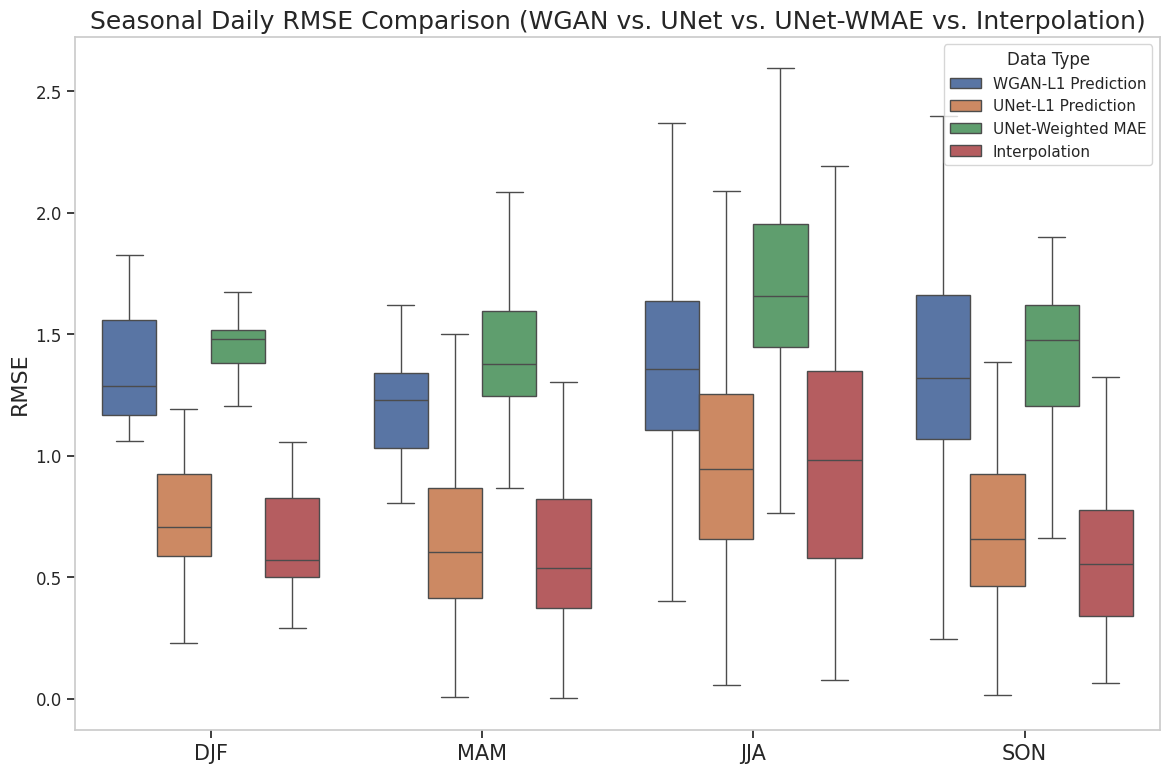

In [40]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 计算按天 RMSE 函数
def calculate_daily_rmse(pred, obs):
    daily_rmse = []
    pred_grouped = pred.groupby('time.date')
    obs_grouped = obs.groupby('time.date')

    for day in pred_grouped.groups:
        pred_data = pred_grouped[day].values.reshape(-1)
        obs_data = obs_grouped[day].values.reshape(-1)
        
        # 避免无效数据
        if np.all(np.isnan(pred_data)) or np.all(np.isnan(obs_data)):
            continue
        
        rmse = np.sqrt(np.mean((pred_data - obs_data) ** 2))
        daily_rmse.append({'date': day, 'rmse': rmse})
    
    return pd.DataFrame(daily_rmse)

# 加载 WGAN-L1 数据集
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan = ds_wgan['fcst']
hr_wgan = ds_wgan['hr']
inter = ds_wgan['inter'] 

# 加载 UNet-L1 数据集
ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet = ds_unet['fcst']
hr_unet = ds_unet['hr']

# 加载 UNet-Weighted MAE 数据集
ds_unet_wmae = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_1_onestep_weightmae_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet_wmae = ds_unet_wmae['fcst']
hr_unet_wmae = ds_unet_wmae['hr']

# 计算 RMSE
df_fcst_wgan = calculate_daily_rmse(fcst_wgan, hr_wgan)
df_fcst_unet = calculate_daily_rmse(fcst_unet, hr_unet)
df_fcst_unet_wmae = calculate_daily_rmse(fcst_unet_wmae, hr_unet_wmae)
df_inter = calculate_daily_rmse(inter, hr_wgan)  

# 添加模型类型和来源
df_fcst_wgan['Type'] = 'WGAN-L1 Prediction'
df_fcst_unet['Type'] = 'UNet-L1 Prediction'
df_fcst_unet_wmae['Type'] = 'UNet-Weighted MAE'
df_inter['Type'] = 'Interpolation'

# 合并数据
df = pd.concat([df_fcst_wgan, df_fcst_unet, df_fcst_unet_wmae, df_inter])

# 转换日期格式
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# 季节映射
def get_season(month):
    if month in [12, 1, 2]:
        return 'DJF'  # 冬季
    elif month in [3, 4, 5]:
        return 'MAM'  # 春季
    elif month in [6, 7, 8]:
        return 'JJA'  # 夏季
    else:
        return 'SON'  # 秋季

df['season'] = df['month'].map(get_season)

# 设置绘图风格
sns.set(style="whitegrid")

# 绘制箱线图
plt.figure(figsize=(14, 9))
sns.boxplot(x='season', y='rmse', hue='Type', data=df,
            order=['DJF', 'MAM', 'JJA', 'SON'],
            showfliers=False)  # 不显示离群点

# 美化图表
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.title('Seasonal Daily RMSE Comparison (WGAN vs. UNet vs. UNet-WMAE vs. Interpolation)', fontsize=18)
plt.xlabel('')  
plt.ylabel('RMSE', fontsize=16)

plt.xticks(fontsize=15)
plt.yticks(fontsize=12)

# 美化细节
plt.grid(False)  
plt.tick_params(axis='x', which='both', bottom=True)
plt.tick_params(axis='y', which='both', left=True)

plt.legend(title='Data Type', loc='upper right')
plt.show()


## 需要老师check

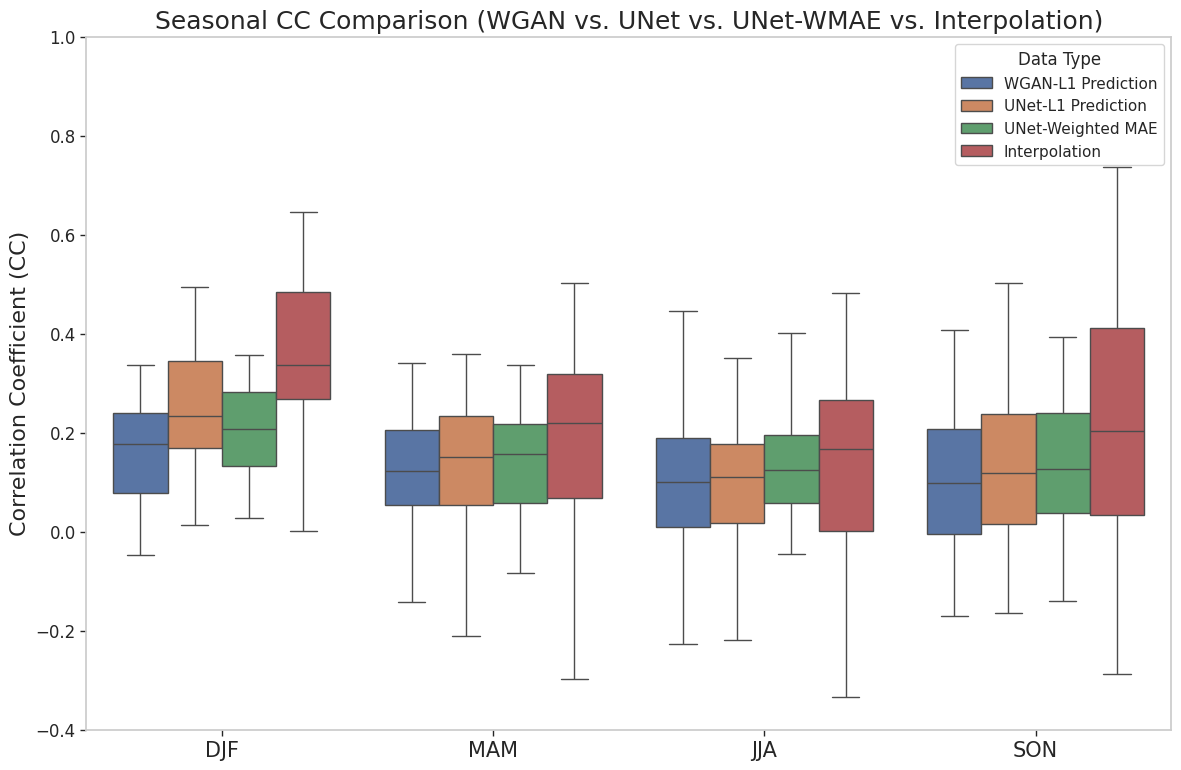

In [41]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 计算按天 CC 函数（考虑降水阈值）
def calculate_daily_cc_with_threshold(pred, obs, threshold=0.1):
    daily_cc = []
    
    pred_grouped = pred.groupby('time.date')
    obs_grouped = obs.groupby('time.date')

    for day in pred_grouped.groups:
        pred_data = pred_grouped[day].values.reshape(-1)
        obs_data = obs_grouped[day].values.reshape(-1)
        
        # 应用阈值过滤，仅保留降水量大于阈值的网格
        mask = obs_data > threshold
        
        # 如果该时间步无有效降水数据，跳过计算
        if np.sum(mask) == 0:
            continue
        
        # 筛选掩码区域的数据
        pred_filtered = pred_data[mask]
        obs_filtered = obs_data[mask]
        
        # 避免标准差为零导致 NaN
        if np.std(pred_filtered) == 0 or np.std(obs_filtered) == 0:
            continue
        
        # 计算相关系数
        cc = np.corrcoef(pred_filtered, obs_filtered)[0, 1]
        daily_cc.append({'date': day, 'cc': cc})
    
    return pd.DataFrame(daily_cc)

# 加载 WGAN-L1 数据集
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan = ds_wgan['fcst']
hr_wgan = ds_wgan['hr']
inter = ds_wgan['inter']  

# 加载 UNet-L1 数据集
ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet = ds_unet['fcst']
hr_unet = ds_unet['hr']

# 加载 UNet-Weighted MAE 数据集
ds_unet_wmae = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_1_onestep_weightmae_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet_wmae = ds_unet_wmae['fcst']
hr_unet_wmae = ds_unet_wmae['hr']

# 计算相关系数（CC）
df_fcst_wgan = calculate_daily_cc_with_threshold(fcst_wgan, hr_wgan)
df_fcst_unet = calculate_daily_cc_with_threshold(fcst_unet, hr_unet)
df_fcst_unet_wmae = calculate_daily_cc_with_threshold(fcst_unet_wmae, hr_unet_wmae)
df_inter = calculate_daily_cc_with_threshold(inter, hr_wgan) 

# 添加模型类型
df_fcst_wgan['Type'] = 'WGAN-L1 Prediction'
df_fcst_unet['Type'] = 'UNet-L1 Prediction'
df_fcst_unet_wmae['Type'] = 'UNet-Weighted MAE'
df_inter['Type'] = 'Interpolation'

# 合并数据
df = pd.concat([df_fcst_wgan, df_fcst_unet, df_fcst_unet_wmae, df_inter])

# 转换日期格式
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# 季节映射
def get_season(month):
    if month in [12, 1, 2]:
        return 'DJF'  # 冬季
    elif month in [3, 4, 5]:
        return 'MAM'  # 春季
    elif month in [6, 7, 8]:
        return 'JJA'  # 夏季
    else:
        return 'SON'  # 秋季

df['season'] = df['month'].map(get_season)

sns.set(style="whitegrid")

# 绘制箱线图
plt.figure(figsize=(14, 9))
sns.boxplot(x='season', y='cc', hue='Type', data=df,
            order=['DJF', 'MAM', 'JJA', 'SON'],
            showfliers=False)  # 不显示离群点

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.title('Seasonal CC Comparison (WGAN vs. UNet vs. UNet-WMAE vs. Interpolation)', fontsize=18)
plt.xlabel('') 
plt.ylabel('Correlation Coefficient (CC)', fontsize=16)
plt.ylim(-0.4, 1)  
plt.legend(title='Data Type', loc='upper right')
plt.xticks(fontsize=15)
plt.yticks(fontsize=12)
plt.grid(False)  
plt.tick_params(axis='x', which='both', bottom=True)
plt.tick_params(axis='y', which='both', left=True)

plt.gca().tick_params(axis='both', which='major', length=4, width=1)  
plt.gca().tick_params(axis='both', which='minor', length=2, width=0.7)  

plt.show()


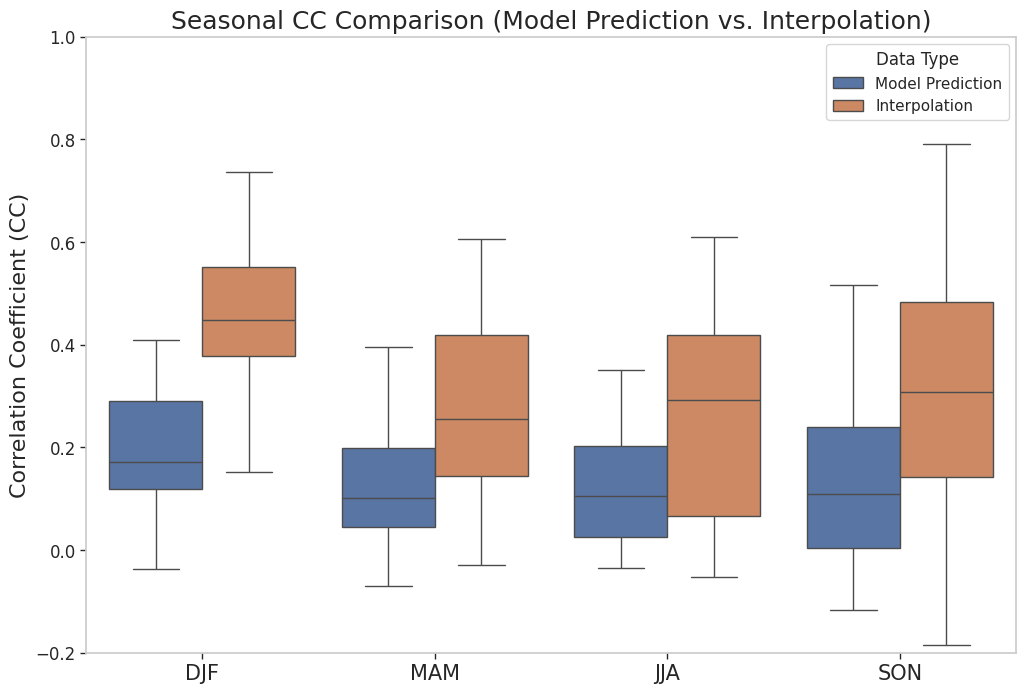

In [13]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")

# 提取变量
fcst = ds['fcst']  # 模型预测结果
hr = ds['hr']      # 高分辨率雷达观测
inter = ds['inter']  # 双三线插值结果
time = pd.to_datetime(ds['time'].values)  # 时间坐标

# 计算每天的相关系数
def calculate_daily_cc(pred, obs):
    daily_cc = []
    
    # 使用groupby分组
    pred_grouped = pred.groupby('time.date')
    obs_grouped = obs.groupby('time.date')

    for day in pred_grouped.groups:
        # 直接迭代获取分组数据
        pred_data = pred_grouped[day]
        obs_data = obs_grouped[day]

        # 展平数据
        pred_flat = pred_data.values.reshape(-1)
        obs_flat = obs_data.values.reshape(-1)
        
        # 处理除零情况，避免NaN
        if np.std(pred_flat) == 0 or np.std(obs_flat) == 0:
            continue  # 跳过标准差为零的情况
        
        # 计算相关系数
        cc = np.corrcoef(pred_flat, obs_flat)[0, 1]
        
        daily_cc.append({'date': day, 'cc': cc})
    
    return pd.DataFrame(daily_cc)

# 计算 fcst 和 inter 相对于 hr 的 CC
df_fcst = calculate_daily_cc(fcst, hr)
df_inter = calculate_daily_cc(inter, hr)

# 合并数据，添加模型类型
df_fcst['Type'] = 'Model Prediction'
df_inter['Type'] = 'Interpolation'
df = pd.concat([df_fcst, df_inter])

# 去除重复索引
df = df.drop_duplicates(subset=['date', 'Type'])

# 将日期转换为 datetime 格式，提取月份和季节
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# 季节映射
def get_season(month):
    if month in [12, 1, 2]:
        return 'DJF'  # 冬季
    elif month in [3, 4, 5]:
        return 'MAM'  # 春季
    elif month in [6, 7, 8]:
        return 'JJA'  # 夏季
    else:
        return 'SON'  # 秋季

df['season'] = df['month'].map(get_season)

# 设置绘图风格
sns.set(style="whitegrid")

# 绘制箱线图，禁用离群点
plt.figure(figsize=(12, 8))
sns.boxplot(x='season', y='cc', hue='Type', data=df,
            order=['DJF', 'MAM', 'JJA', 'SON'],
            showfliers=False)  # 不显示离群点

# 美化图表
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.title('Seasonal CC Comparison (Model Prediction vs. Interpolation)', fontsize=18)
plt.xlabel('') 
plt.ylabel('Correlation Coefficient (CC)', fontsize=16)
plt.ylim(-0.2, 1)  
plt.legend(title='Data Type', loc='upper right')
plt.xticks(fontsize=15)
plt.yticks(fontsize=12)
plt.grid(False)  
plt.tick_params(axis='x', which='both', bottom=True, top=False)  
plt.tick_params(axis='y', which='both', left=True, right=False)  

# 设置小刻度
plt.gca().tick_params(axis='both', which='major', length=4, width=1)  
plt.gca().tick_params(axis='both', which='minor', length=2, width=0.7)  

plt.show()


In [6]:
import numpy as np

ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_4_onestep_l1_nofc_aheadtop_10/prcp_downs_unet_year_2020.nc")

inter = ds['inter'].values  # 模型预测结果
hr = ds['hr'].values      # 高分辨率观测数据

# 计算RMSE
rmse = np.sqrt(np.mean((inter - hr) ** 2))

# 计算相关系数（CC）
cc = np.corrcoef(inter.flatten(), hr.flatten())[0, 1]

print(f"RMSE: {rmse:.4f}")
print(f"Correlation Coefficient (CC): {cc:.4f}")


RMSE: 0.9042
Correlation Coefficient (CC): 0.4766


In [13]:
import xarray as xr
import numpy as np

# 加载数据
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_4_onestep_l1_nofc_aheadtop_10/prcp_downs_unet_year_2020.nc") 

# 计算 Individual Prediction RMSE
mse_individual = ((ds['inter'] - ds['hr']) ** 2).mean(dim=['lat', 'lon'])  # 空间均方误差
rmse_individual = np.sqrt(mse_individual.mean())  # 时间维度平均并开方

# 计算 Ensemble-Mean RMSE
ensemble_mean = ds['inter'].mean(dim='time')  # 集合平均
mse_ensemble_mean = ((ensemble_mean - ds['hr']) ** 2).mean(dim=['lat', 'lon'])  # 空间均方误差
rmse_ensemble_mean = np.sqrt(mse_ensemble_mean.mean())  # 时间维度平均并开方

# 计算相关系数 CC
def calculate_correlation(fcst, hr):
    fcst_mean = fcst.mean(dim=['lat', 'lon'])  # 预测均值
    hr_mean = hr.mean(dim=['lat', 'lon'])      # 真实值均值

    numerator = ((fcst - fcst_mean) * (hr - hr_mean)).sum(dim=['lat', 'lon'])  # 协方差部分
    denominator = np.sqrt(
        ((fcst - fcst_mean) ** 2).sum(dim=['lat', 'lon']) *
        ((hr - hr_mean) ** 2).sum(dim=['lat', 'lon'])
    )  # 标准差乘积

    cc = (numerator / denominator).mean()  # 计算时间平均 CC
    return cc

# 计算并输出 CC
cc_score = calculate_correlation(ds['inter'], ds['hr'])

# 输出结果
print(f"Individual Prediction RMSE (Mean): {rmse_individual.values:.4f}")
print(f"Ensemble-Mean RMSE: {rmse_ensemble_mean.values:.4f}")
print(f"Correlation Coefficient (CC): {cc_score.values:.4f}")


Individual Prediction RMSE (Mean): 0.9042
Ensemble-Mean RMSE: 0.9848
Correlation Coefficient (CC): 0.2073


In [3]:
import numpy as np

ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_4_onestep_l1_nofc_aheadtop_10/prcp_downs_unet_year_2020.nc")

fcst = ds['fcst'].values  # 模型预测结果
hr = ds['hr'].values      # 高分辨率观测数据

# 计算RMSE
rmse = np.sqrt(np.mean((fcst - hr) ** 2))

# 计算相关系数（CC）
cc = np.corrcoef(fcst.flatten(), hr.flatten())[0, 1]

print(f"RMSE: {rmse:.4f}")
print(f"Correlation Coefficient (CC): {cc:.4f}")


RMSE: 0.9987
Correlation Coefficient (CC): 0.2891


In [17]:
import xarray as xr
import numpy as np

# 加载数据
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_4_onestep_l1_nofc_aheadtop_10/prcp_downs_unet_year_2020.nc") 

# 计算 Individual Prediction RMSE
mse_individual = ((ds['fcst'] - ds['hr']) ** 2).mean(dim=['lat', 'lon'])  # 空间均方误差
rmse_individual = np.sqrt(mse_individual.mean())  # 时间维度平均并开方

# 计算 Ensemble-Mean RMSE
ensemble_mean = ds['fcst'].mean(dim='time')  # 集合平均
mse_ensemble_mean = ((ensemble_mean - ds['hr']) ** 2).mean(dim=['lat', 'lon'])  # 空间均方误差
rmse_ensemble_mean = np.sqrt(mse_ensemble_mean.mean())  # 时间维度平均并开方

# 计算相关系数 CC
def calculate_correlation(fcst, hr):
    fcst_mean = fcst.mean(dim=['lat', 'lon'])  # 预测均值
    hr_mean = hr.mean(dim=['lat', 'lon'])      # 真实值均值

    numerator = ((fcst - fcst_mean) * (hr - hr_mean)).sum(dim=['lat', 'lon'])  # 协方差部分
    denominator = np.sqrt(
        ((fcst - fcst_mean) ** 2).sum(dim=['lat', 'lon']) *
        ((hr - hr_mean) ** 2).sum(dim=['lat', 'lon'])
    )  # 标准差乘积

    cc = (numerator / denominator).mean()  # 计算时间平均 CC
    return cc

# 计算并输出 CC
cc_score = calculate_correlation(ds['fcst'], ds['hr'])

# 输出结果
print(f"Individual Prediction RMSE (Mean): {rmse_individual.values:.4f}")
print(f"Ensemble-Mean RMSE: {rmse_ensemble_mean.values:.4f}")
print(f"Correlation Coefficient (CC): {cc_score.values:.4f}")


Individual Prediction RMSE (Mean): 0.9987
Ensemble-Mean RMSE: 1.0102
Correlation Coefficient (CC): 0.1434


In [4]:
import numpy as np

ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_5_onestep_l1_nofc_aheadtop_5_addprecipnorm/prcp_downs_unet_year_2020.nc")

fcst = ds['fcst'].values  # 模型预测结果
hr = ds['hr'].values      # 高分辨率观测数据

# 计算RMSE
rmse = np.sqrt(np.mean((fcst - hr) ** 2))

# 计算相关系数（CC）
cc = np.corrcoef(fcst.flatten(), hr.flatten())[0, 1]

print(f"RMSE: {rmse:.4f}")
print(f"Correlation Coefficient (CC): {cc:.4f}")


RMSE: 1.6938
Correlation Coefficient (CC): 0.2512


In [15]:
import xarray as xr
import numpy as np

# 加载数据
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_5_onestep_l1_nofc_aheadtop_5_addprecipnorm/prcp_downs_unet_year_2020.nc") 

# 计算 Individual Prediction RMSE
mse_individual = ((ds['fcst'] - ds['hr']) ** 2).mean(dim=['lat', 'lon'])  # 空间均方误差
rmse_individual = np.sqrt(mse_individual.mean())  # 时间维度平均并开方

# 计算 Ensemble-Mean RMSE
ensemble_mean = ds['fcst'].mean(dim='time')  # 集合平均
mse_ensemble_mean = ((ensemble_mean - ds['hr']) ** 2).mean(dim=['lat', 'lon'])  # 空间均方误差
rmse_ensemble_mean = np.sqrt(mse_ensemble_mean.mean())  # 时间维度平均并开方

# 计算相关系数 CC
def calculate_correlation(fcst, hr):
    fcst_mean = fcst.mean(dim=['lat', 'lon'])  # 预测均值
    hr_mean = hr.mean(dim=['lat', 'lon'])      # 真实值均值

    numerator = ((fcst - fcst_mean) * (hr - hr_mean)).sum(dim=['lat', 'lon'])  # 协方差部分
    denominator = np.sqrt(
        ((fcst - fcst_mean) ** 2).sum(dim=['lat', 'lon']) *
        ((hr - hr_mean) ** 2).sum(dim=['lat', 'lon'])
    )  # 标准差乘积

    cc = (numerator / denominator).mean()  # 计算时间平均 CC
    return cc

# 计算并输出 CC
cc_score = calculate_correlation(ds['fcst'], ds['hr'])

# 输出结果
print(f"Individual Prediction RMSE (Mean): {rmse_individual.values:.4f}")
print(f"Ensemble-Mean RMSE: {rmse_ensemble_mean.values:.4f}")
print(f"Correlation Coefficient (CC): {cc_score.values:.4f}")


Individual Prediction RMSE (Mean): 1.6938
Ensemble-Mean RMSE: 1.7033
Correlation Coefficient (CC): 0.1360


In [25]:
import numpy as np
import xarray as xr
import pandas as pd

# 加载数据
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")

fcst = ds['inter']
hr = ds['hr']

# 按天分组
fcst_grouped = fcst.groupby('time.date')
hr_grouped = hr.groupby('time.date')

# 初始化存储每日 RMSE 和 CC 的列表
daily_rmse = []
daily_cc = []
dates = []

# 逐天计算
for day in fcst_grouped.groups:
    fcst_daily = fcst_grouped[day].values.reshape(-1)
    hr_daily = hr_grouped[day].values.reshape(-1)
    
    # 计算 RMSE
    rmse = np.sqrt(np.mean((fcst_daily - hr_daily) ** 2))
    daily_rmse.append(rmse)
    
    # 计算 CC
    if np.std(fcst_daily) > 0 and np.std(hr_daily) > 0:
        cc = np.corrcoef(fcst_daily, hr_daily)[0, 1]
    else:
        cc = np.nan  # 如果标准差为0，无法计算相关系数
    daily_cc.append(cc)
    
    # 存储日期
    dates.append(day)

# 转换为 DataFrame
results_df = pd.DataFrame({
    'Date': dates,
    'RMSE': daily_rmse,
    'CC': daily_cc
})

# 计算平均值
average_rmse = np.nanmean(daily_rmse)
average_cc = np.nanmean(daily_cc)

print("Daily RMSE and CC:")
print(results_df)

print("\nAverage RMSE and CC:")
print(f"Average RMSE: {average_rmse:.4f}")
print(f"Average CC: {average_cc:.4f}")



Daily RMSE and CC:
           Date      RMSE        CC
0    2020-02-01  0.890132  0.621154
1    2020-02-02  0.849281  0.377065
2    2020-02-03  0.906053  0.672580
3    2020-02-04  0.719709  0.718901
4    2020-02-05  0.296485  0.236915
..          ...       ...       ...
186  2020-11-20  0.387142  0.248312
187  2020-11-22  0.223945  0.120580
188  2020-11-26  0.105266  0.375999
189  2020-11-30  0.553199  0.547497
190  2020-12-01  0.571328  0.453908

[191 rows x 3 columns]

Average RMSE and CC:
Average RMSE: 0.7616
Average CC: 0.3096


In [26]:
results_df

,Date,RMSE,CC
0,2020-02-01,0.890132,0.621154
1,2020-02-02,0.849281,0.377065
2,2020-02-03,0.906053,0.672580
3,2020-02-04,0.719709,0.718901
4,2020-02-05,0.296485,0.236915
...,...,...,...
186,2020-11-20,0.387142,0.248312
187,2020-11-22,0.223945,0.120580
188,2020-11-26,0.105266,0.375999
189,2020-11-30,0.553199,0.547497


In [27]:
# 查找 CC 小于零的行
cc_negative = results_df[results_df['CC'] < 0]

print(f"Number of CC < 0: {len(cc_negative)}")
print("Dates with CC < 0:")
print(cc_negative)


Number of CC < 0: 18
Dates with CC < 0:
           Date      RMSE        CC
39   2020-03-14  0.270918 -0.029623
46   2020-04-15  0.005690 -0.018005
50   2020-04-27  0.407278 -0.029130
74   2020-06-08  0.404090 -0.027661
78   2020-06-13  3.193049 -0.045677
83   2020-06-18  1.433574 -0.051998
86   2020-06-22  0.323403 -0.004100
88   2020-06-27  1.737285 -0.010961
96   2020-07-05  0.258591 -0.013328
112  2020-08-02  2.043190 -0.001826
116  2020-08-14  2.095660 -0.002757
118  2020-08-16  0.954638 -0.008834
121  2020-08-19  0.077148 -0.009061
134  2020-09-04  0.451850 -0.185958
136  2020-09-06  0.092426 -0.001217
137  2020-09-07  0.115932 -0.002676
156  2020-10-11  0.247250 -0.012289
180  2020-11-11  0.065463 -0.009651
